# ============================================================
# DIVVY BIKES — EXPLORATORY DATA ANALYSIS
# Author: ASWIN GEORGE
# ============================================================

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# --- Display Settings ---
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.max_rows', 100)       # Show up to 100 rows
pd.set_option('display.float_format', '{:.2f}'.format)  # Clean decimals

# --- Plot Styling ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# --- Warnings ---
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [7]:
# ============================================================
# Load Each Excel File Individually
# ============================================================

df1 = pd.read_csv("data/202602-divvy-tripdata.csv")
df2 = pd.read_csv("data/202603-divvy-tripdata.csv")
df3 = pd.read_csv("data/202604-divvy-tripdata.csv")

print("✅ Files loaded successfully!")
print(f"\nFile 1 shape: {df1.shape}")
print(f"File 2 shape: {df2.shape}")
print(f"File 3 shape: {df3.shape}")

✅ Files loaded successfully!

File 1 shape: (201450, 13)
File 2 shape: (317037, 13)
File 3 shape: (448252, 13)


In [8]:
# ============================================================
# Compare Column Names
# ============================================================

print("=== FILE 1 COLUMNS ===")
print(df1.columns.tolist())

print("\n=== FILE 2 COLUMNS ===")
print(df2.columns.tolist())

print("\n=== FILE 3 COLUMNS ===")
print(df3.columns.tolist())

# Check if all columns match exactly
cols_match_12 = set(df1.columns) == set(df2.columns)
cols_match_13 = set(df1.columns) == set(df3.columns)

print(f"\n✅ File1 & File2 columns match: {cols_match_12}")
print(f"✅ File1 & File3 columns match: {cols_match_13}")

# Show any mismatched columns
print("\nColumns in File1 but NOT in File2:", set(df1.columns) - set(df2.columns))
print("Columns in File2 but NOT in File1:", set(df2.columns) - set(df1.columns))

=== FILE 1 COLUMNS ===
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

=== FILE 2 COLUMNS ===
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

=== FILE 3 COLUMNS ===
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

✅ File1 & File2 columns match: True
✅ File1 & File3 columns match: True

Columns in File1 but NOT in File2: set()
Columns in File2 but NOT in File1: set()


In [9]:
# ============================================================
# Type comparison
# ============================================================

type_comparison = pd.DataFrame({
    'File1_dtype': df1.dtypes,
    'File2_dtype': df2.dtypes,
    'File3_dtype': df3.dtypes
})

print(type_comparison)

                   File1_dtype File2_dtype File3_dtype
ride_id                    str         str         str
rideable_type              str         str         str
started_at                 str         str         str
ended_at                   str         str         str
start_station_name         str         str         str
start_station_id           str         str         str
end_station_name           str         str         str
end_station_id             str         str         str
start_lat              float64     float64     float64
start_lng              float64     float64     float64
end_lat                float64     float64     float64
end_lng                float64     float64     float64
member_casual              str         str         str


In [22]:
# ============================================================
# Concatenate All Files Into One Master DataFrame
# ============================================================

df = pd.concat([df1, df2, df3], ignore_index=True)

print(f"✅ Combined dataset shape: {df.shape}")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.columns.tolist()}")


✅ Combined dataset shape: (966739, 13)
Total rows: 966,739
Total columns: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


In [25]:
# ============================================================
# Basic Structure
# ============================================================

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nShape       : {df.shape}")
print(f"Total Rows  : {df.shape[0]:,}")
print(f"Total Cols  : {df.shape[1]}")

print("\n--- Column Names & Data Types ---")
print(df.dtypes)

DATASET OVERVIEW

Shape       : (966739, 13)
Total Rows  : 966,739
Total Cols  : 13

--- Column Names & Data Types ---
ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object


In [26]:
# ============================================================
# Missing Values Analysis
# ============================================================

print("=" * 50)
print("MISSING VALUES REPORT")
print("=" * 50)

missing = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().sum() / len(df) * 100).round(2)
})

# Only show columns that actually have missing values
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(missing.to_string())
print(f"\nColumns with NO missing values: "
      f"{df.shape[1] - len(missing)}/{df.shape[1]}")

MISSING VALUES REPORT
                    Missing Count  Missing %
end_station_id             191904      19.85
end_station_name           191904      19.85
start_station_id           181832      18.81
start_station_name         181832      18.81
end_lat                       774       0.08
end_lng                       774       0.08

Columns with NO missing values: 7/13


In [31]:
# ============================================================
# Explore Categorical Columns
# ============================================================

print("=" * 50)
print("CATEGORICAL COLUMNS")
print("=" * 50)

# cat_cols = ['rideable_type', 'member_casual']
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")
    print(f"Null count   : {df[col].isnull().sum()}")

CATEGORICAL COLUMNS

--- ride_id ---
ride_id
4194C9D5CAFDBE7C    1
790A93E87E5EE83C    1
21ABD91CD9FB7D13    1
8D97FE9075293A3B    1
03A65D965372A020    1
                   ..
3EBF5095F5EDD850    1
9E8DA9D139892463    1
37C480C304D1D8C1    1
27B1BFA25C7449F4    1
5610B1C41963BAD1    1
Name: count, Length: 966739, dtype: int64
Unique values: 966739
Null count   : 0

--- rideable_type ---
rideable_type
electric_bike    670409
classic_bike     296330
Name: count, dtype: int64
Unique values: 2
Null count   : 0

--- started_at ---
started_at
2026-02-19 08:52:00.820    2
2026-02-04 06:26:31.539    2
2026-02-20 18:39:34.653    2
2026-02-16 12:47:44.521    2
2026-02-27 15:10:17.349    2
                          ..
2026-04-30 17:28:33.339    1
2026-04-29 18:54:07.910    1
2026-04-09 15:49:52.265    1
2026-04-21 15:37:19.424    1
2026-04-14 17:14:32.550    1
Name: count, Length: 966618, dtype: int64
Unique values: 966618
Null count   : 0

--- ended_at ---
ended_at
2026-02-25 12:20:40.768    14

In [33]:
# ============================================================
# Verify Date Columns
# ============================================================

print("--- Date Column Types ---")
print(f"started_at dtype : {df['started_at'].dtype}")
print(f"ended_at dtype   : {df['ended_at'].dtype}")

print("\n--- Date Range ---")
print(f"Earliest ride : {df['started_at'].min()}")
print(f"Latest ride   : {df['started_at'].max()}")

--- Date Column Types ---
started_at dtype : str
ended_at dtype   : str

--- Date Range ---
Earliest ride : 2026-01-31 11:08:07.830
Latest ride   : 2026-04-30 23:58:56.151


In [34]:
# ============================================================
# Summary Statistics
# ============================================================

print("=" * 50)
print("SUMMARY STATISTICS — NUMERIC COLUMNS")
print("=" * 50)

print(df.describe())

SUMMARY STATISTICS — NUMERIC COLUMNS
       start_lat  start_lng   end_lat   end_lng
count  966739.00  966739.00 965965.00 965965.00
mean       41.90     -87.65     41.90    -87.65
std         0.05       0.03      0.05      0.03
min        41.65     -87.86     41.63    -87.91
25%        41.88     -87.66     41.88    -87.66
50%        41.90     -87.64     41.90    -87.64
75%        41.93     -87.63     41.93    -87.63
max        42.07     -87.53     42.12    -87.53


In [35]:
# ============================================================
# Duplicate Check
# ============================================================

total_dupes = df.duplicated().sum()
ride_id_dupes = df['ride_id'].duplicated().sum()

print(f"Fully duplicate rows     : {total_dupes:,}")
print(f"Duplicate ride_id values : {ride_id_dupes:,}")

if ride_id_dupes > 0:
    print("\n⚠️  WARNING: Duplicate ride_ids detected!")
    print(df[df['ride_id'].duplicated(keep=False)].head())
else:
    print("\n✅ All ride_ids are unique — no duplicates found!")

Fully duplicate rows     : 0
Duplicate ride_id values : 0

✅ All ride_ids are unique — no duplicates found!


In [36]:
# ============================================================
# Convert Date Strings → Datetime Objects
# ============================================================

df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at']   = pd.to_datetime(df['ended_at'])

# Verify conversion worked
print("After conversion:")
print(f"started_at dtype : {df['started_at'].dtype}")
print(f"ended_at dtype   : {df['ended_at'].dtype}")

print("\nSample values:")
print(df[['started_at', 'ended_at']].head(3))

After conversion:
started_at dtype : datetime64[us]
ended_at dtype   : datetime64[us]

Sample values:
               started_at                ended_at
0 2026-02-08 17:08:34.392 2026-02-08 17:13:57.661
1 2026-02-08 14:44:11.880 2026-02-08 14:48:14.329
2 2026-02-08 14:38:03.488 2026-02-08 14:41:19.976


In [37]:
# ============================================================
# Calculate Trip Duration in Minutes
# ============================================================

df['trip_duration_mins'] = (
    df['ended_at'] - df['started_at']
).dt.total_seconds() / 60

print("Trip Duration — Quick Stats:")
print(df['trip_duration_mins'].describe().round(2))

print(f"\nNegative durations : {(df['trip_duration_mins'] < 0).sum():,}")
print(f"Zero durations     : {(df['trip_duration_mins'] == 0).sum():,}")
print(f"Under 1 minute     : {(df['trip_duration_mins'] < 1).sum():,}")
print(f"Over 24 hours      : {(df['trip_duration_mins'] > 1440).sum():,}")

Trip Duration — Quick Stats:
count   966739.00
mean        13.47
std         47.46
min          0.00
25%          4.72
50%          8.11
75%         14.19
max       1559.95
Name: trip_duration_mins, dtype: float64

Negative durations : 0
Zero durations     : 0
Under 1 minute     : 24,728
Over 24 hours      : 737


In [38]:
# ============================================================
# Remove Invalid Trip Durations
# WHY:
# - Negative duration = ended_at is BEFORE started_at
#   → data entry error, impossible in real life
# - Under 1 minute = likely a false start or dock test
#   → not a real trip, will skew averages downward
# - Over 24 hours = bike was likely stolen or not returned
#   → extreme outlier, will skew averages upward
#
# Industry standard for Divvy: keep trips between 1–1440 mins
# ============================================================

rows_before = len(df)

df = df[
    (df['trip_duration_mins'] >= 1) &
    (df['trip_duration_mins'] <= 1440)
].copy()

rows_after = len(df)
rows_removed = rows_before - rows_after

print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after cleaning  : {rows_after:,}")
print(f"Rows removed         : {rows_removed:,} "
      f"({rows_removed/rows_before*100:.2f}%)")
print(f"\n✅ Dataset now contains only valid trips.")

Rows before cleaning : 966,739
Rows after cleaning  : 941,274
Rows removed         : 25,465 (2.63%)

✅ Dataset now contains only valid trips.


In [39]:
# ============================================================
# Investigate Missing Station Names
# ============================================================

# How many rows have missing station info?
missing_start = df['start_station_name'].isnull().sum()
missing_end   = df['end_station_name'].isnull().sum()
total         = len(df)

print("Missing Station Names:")
print(f"  start_station_name : {missing_start:,} "
      f"({missing_start/total*100:.1f}%)")
print(f"  end_station_name   : {missing_end:,} "
      f"({missing_end/total*100:.1f}%)")

# KEY QUESTION: Are missing stations linked to electric bikes?
print("\n--- Rideable Type Breakdown for Missing Start Stations ---")
print(
    df[df['start_station_name'].isnull()]['rideable_type']
    .value_counts()
)

print("\n--- Member Type Breakdown for Missing Start Stations ---")
print(
    df[df['start_station_name'].isnull()]['member_casual']
    .value_counts()
)

Missing Station Names:
  start_station_name : 168,282 (17.9%)
  end_station_name   : 174,981 (18.6%)

--- Rideable Type Breakdown for Missing Start Stations ---
rideable_type
electric_bike    168282
Name: count, dtype: int64

--- Member Type Breakdown for Missing Start Stations ---
member_casual
member    122695
casual     45587
Name: count, dtype: int64


In [40]:
# ============================================================
# Handle Missing Station Names
# WHY: Electric bikes can be locked to street posts (not docking stations), so station name is genuinely unknown.
# We DO NOT drop these rows — they represent real trips.
# Instead we label them clearly so analysis stays honest.
# ============================================================

df['start_station_name'] = df['start_station_name'].fillna('Unknown Station')
df['end_station_name']   = df['end_station_name'].fillna('Unknown Station')
df['start_station_id']   = df['start_station_id'].fillna('Unknown')
df['end_station_id']     = df['end_station_id'].fillna('Unknown')

print("✅ Missing station names filled with 'Unknown Station'")
print(f"Remaining nulls in start_station_name: "
      f"{df['start_station_name'].isnull().sum()}")
print(f"Remaining nulls in end_station_name  : "
      f"{df['end_station_name'].isnull().sum()}")

✅ Missing station names filled with 'Unknown Station'
Remaining nulls in start_station_name: 0
Remaining nulls in end_station_name  : 0


In [41]:
# ============================================================
# Final Validation — Is Our Dataset Clean?
# ============================================================

print("=" * 55)
print("FINAL CLEANING VALIDATION REPORT")
print("=" * 55)

print(f"\nFinal shape          : {df.shape}")
print(f"Total rides          : {len(df):,}")

print("\n--- Null Values Remaining ---")
nulls = df.isnull().sum()
print(nulls[nulls > 0])

print("\n--- Trip Duration Range ---")
print(f"  Min : {df['trip_duration_mins'].min():.2f} mins")
print(f"  Max : {df['trip_duration_mins'].max():.2f} mins")
print(f"  Avg : {df['trip_duration_mins'].mean():.2f} mins")
print(f"  Med : {df['trip_duration_mins'].median():.2f} mins")

print("\n--- Rideable Types ---")
print(df['rideable_type'].value_counts())

print("\n--- Member vs Casual ---")
print(df['member_casual'].value_counts())

print("\n--- Date Range ---")
print(f"  From : {df['started_at'].min()}")
print(f"  To   : {df['started_at'].max()}")

print("\n✅ Dataset is clean and ready for Feature Engineering!")

FINAL CLEANING VALIDATION REPORT

Final shape          : (941274, 14)
Total rides          : 941,274

--- Null Values Remaining ---
end_lat    62
end_lng    62
dtype: int64

--- Trip Duration Range ---
  Min : 1.00 mins
  Max : 1431.96 mins
  Avg : 12.65 mins
  Med : 8.32 mins

--- Rideable Types ---
rideable_type
electric_bike    645681
classic_bike     295593
Name: count, dtype: int64

--- Member vs Casual ---
member_casual
member    689362
casual    251912
Name: count, dtype: int64

--- Date Range ---
  From : 2026-01-31 14:42:43.536000
  To   : 2026-04-30 23:58:56.151000

✅ Dataset is clean and ready for Feature Engineering!


In [42]:
# ============================================================
# Extract Time-Based Features from started_at
# WHY: A single timestamp contains MULTIPLE useful dimensions.
# Extracting them as separate columns makes every analysis faster to write and easier to interpret.
# ============================================================

# Hour of day (0–23)
df['hour'] = df['started_at'].dt.hour

# Day of week (0=Monday ... 6=Sunday)
df['day_of_week'] = df['started_at'].dt.day_name()

# Month name
df['month'] = df['started_at'].dt.month_name()

# Month number (for correct sorting later)
df['month_num'] = df['started_at'].dt.month

# Day number (for correct sorting later)
df['day_num'] = df['started_at'].dt.dayofweek

# Date only (useful for daily trend plots)
df['date'] = df['started_at'].dt.date

print("✅ Time features extracted!")
print(df[['started_at', 'hour', 'day_of_week',
          'month', 'month_num']].head(5))

✅ Time features extracted!
                started_at  hour day_of_week     month  month_num
0  2026-02-08 17:08:34.392    17      Sunday  February          2
1  2026-02-08 14:44:11.880    14      Sunday  February          2
2  2026-02-08 14:38:03.488    14      Sunday  February          2
27 2026-02-09 17:58:50.551    17      Monday  February          2
28 2026-02-10 19:00:37.649    19     Tuesday  February          2


In [48]:
# ============================================================
# Create Weekday vs Weekend Feature
# ============================================================

# day_num: 0=Monday, 1=Tue, 2=Wed, 3=Thu, 4=Fri,
#           5=Saturday, 6=Sunday
df['is_weekend'] = df['day_num'].isin([5, 6])
df['day_type'] = df['is_weekend'].map(
    {True: 'Weekend', False: 'Weekday'}
)

print("Weekday vs Weekend Split:")
print(df['day_type'].value_counts())
print(f"\nWeekend % : "
      f"{df['is_weekend'].mean()*100:.1f}%")

Weekday vs Weekend Split:
day_type
Weekday    714676
Weekend    226598
Name: count, dtype: int64

Weekend % : 24.1%


In [51]:
# ============================================================
# Categorize Trip Durations
# ============================================================

bins   = [0, 5, 15, 30, 60, 1440]
labels = ['Very Short (<5 min)',
          'Short (5–15 min)',
          'Medium (15–30 min)',
          'Long (30–60 min)',
          'Very Long (>60 min)']

df['duration_category'] = pd.cut(
    df['trip_duration_mins'],
    bins=bins,
    labels=labels
)

print("Trip Duration Categories:")
print(df['duration_category'].value_counts().sort_index())
print(f"\nAs percentages:")
print(
    (df['duration_category'].value_counts(normalize=True)
     * 100).round(1).sort_index()
)

Trip Duration Categories:
duration_category
Very Short (<5 min)    240150
Short (5–15 min)       479290
Medium (15–30 min)     160248
Long (30–60 min)        49051
Very Long (>60 min)     12535
Name: count, dtype: int64

As percentages:
duration_category
Very Short (<5 min)   25.50
Short (5–15 min)      50.90
Medium (15–30 min)    17.00
Long (30–60 min)       5.20
Very Long (>60 min)    1.30
Name: proportion, dtype: float64


In [54]:
# ============================================================
# Time of Day Category
# WHY: Grouping hours into named periods makes peak-hour analysis much more readable and business-friendly.
# "Morning Rush" is clearer than "Hours 7, 8, 9".
# ============================================================

def get_time_of_day(hour):
    if 5 <= hour < 9:
        return '🌅 Early Morning (5–9am)'
    elif 9 <= hour < 12:
        return '🌤️ Morning (9–12pm)'
    elif 12 <= hour < 17:
        return '☀️ Afternoon (12–5pm)'
    elif 17 <= hour < 21:
        return '🌆 Evening (5–9pm)'
    else:
        return '🌙 Night (9pm–5am)'

df['time_of_day'] = df['hour'].apply(get_time_of_day)

print("Rides by Time of Day:")
print(df['time_of_day'].value_counts())

Rides by Time of Day:
time_of_day
☀️ Afternoon (12–5pm)      323471
🌆 Evening (5–9pm)          268788
🌅 Early Morning (5–9am)    143973
🌤️ Morning (9–12pm)        122381
🌙 Night (9pm–5am)           82661
Name: count, dtype: int64


In [55]:
# ============================================================
# Confirm All New Features Look Correct
# ============================================================

print("=" * 55)
print("FEATURE ENGINEERING — VALIDATION")
print("=" * 55)

print(f"\nFinal shape : {df.shape}")
print(f"\nAll columns now:")
print(df.columns.tolist())

print("\n--- Sample Row (Full) ---")
sample = df[['started_at', 'trip_duration_mins',
             'hour', 'day_of_week', 'day_type',
             'month', 'duration_category',
             'time_of_day', 'member_casual']].head(5)
print(sample.to_string())

print("\n--- Quick Sanity Checks ---")

# Check: does hour range 0-23?
print(f"Hour range       : {df['hour'].min()} "
      f"to {df['hour'].max()} ✅")

# Check: are all months in our expected range?
print(f"Months present   : "
      f"{sorted(df['month_num'].unique())}")

# Check: trip_duration all positive?
print(f"Min duration     : "
      f"{df['trip_duration_mins'].min():.2f} mins ✅")

print("\n✅ All features validated! Ready for EDA.")

FEATURE ENGINEERING — VALIDATION

Final shape : (941274, 24)

All columns now:
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual', 'trip_duration_mins', 'hour', 'day_of_week', 'month', 'month_num', 'day_num', 'date', 'is_weekend', 'day_type', 'duration_category', 'time_of_day']

--- Sample Row (Full) ---
                started_at  trip_duration_mins  hour day_of_week day_type     month    duration_category            time_of_day member_casual
0  2026-02-08 17:08:34.392                5.39    17      Sunday  Weekend  February     Short (5–15 min)      🌆 Evening (5–9pm)        member
1  2026-02-08 14:44:11.880                4.04    14      Sunday  Weekend  February  Very Short (<5 min)  ☀️ Afternoon (12–5pm)        member
2  2026-02-08 14:38:03.488                3.27    14      Sunday  Weekend  February  Very Short (<5 min)  ☀️ Afternoon (

# **Exploratory Data Analysis & Visualizations**

## **📊 SECTION 1 — Understanding the Users**

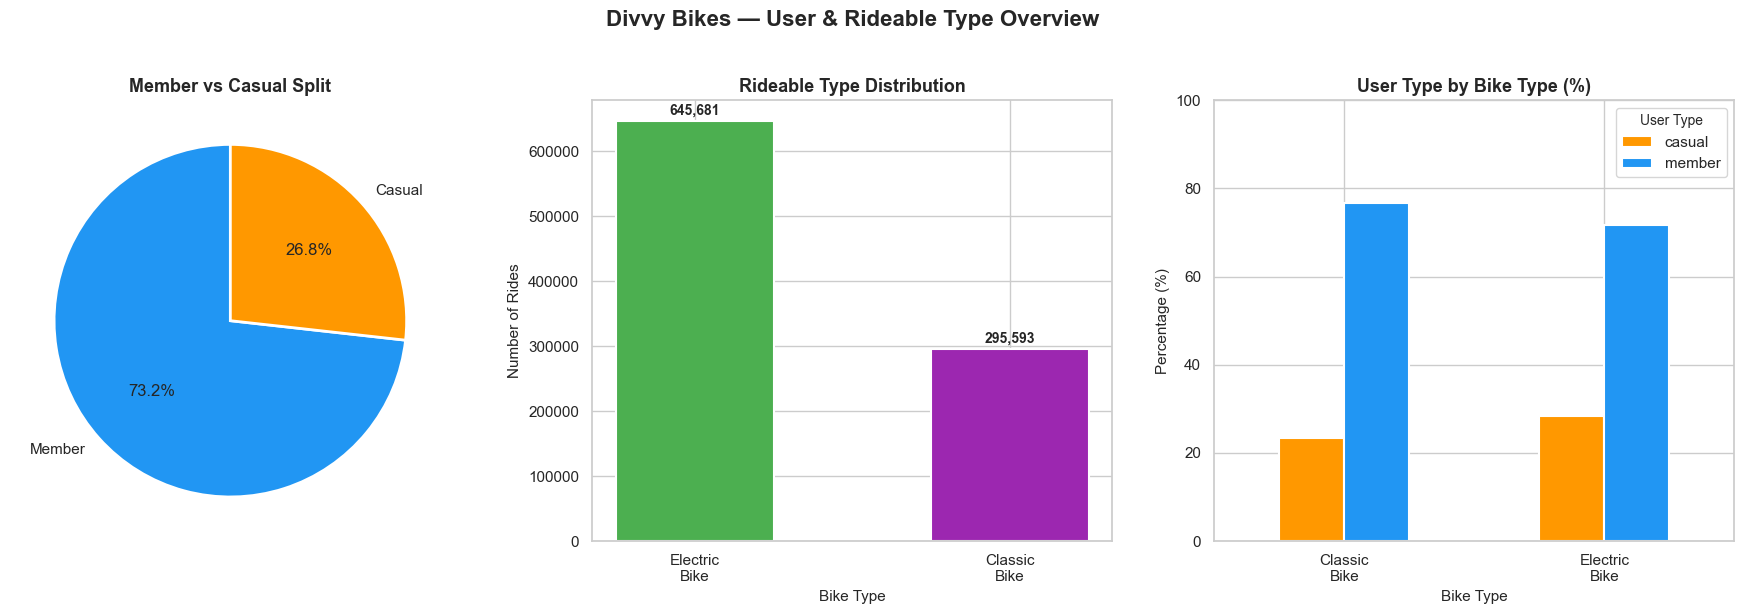

SUMMARY — USER & RIDEABLE TYPE

Total rides : 941,274

By User Type:
member_casual
member    689362
casual    251912

By Bike Type:
rideable_type
electric_bike    645681
classic_bike     295593


In [56]:
# ============================================================
# ANALYSIS 1.1: User Type & Rideable Type Distribution
# BUSINESS QUESTION: Who are our users and what bikes do they prefer? This tells us who to target in marketing and which bike fleet to prioritize.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Divvy Bikes — User & Rideable Type Overview',
             fontsize=16, fontweight='bold', y=1.02)

# --- Plot 1: Member vs Casual (Pie) ---
member_counts = df['member_casual'].value_counts()
colors_pie = ['#2196F3', '#FF9800']

axes[0].pie(
    member_counts,
    labels=member_counts.index.str.title(),
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Member vs Casual Split',
                  fontsize=13, fontweight='bold')

# --- Plot 2: Rideable Type (Bar) ---
bike_counts = df['rideable_type'].value_counts()
bars = axes[1].bar(
    bike_counts.index.str.replace('_', '\n').str.title(),
    bike_counts.values,
    color=['#4CAF50', '#9C27B0'],
    edgecolor='white', linewidth=1.5,
    width=0.5
)
axes[1].set_title('Rideable Type Distribution',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Rides', fontsize=11)
axes[1].set_xlabel('Bike Type', fontsize=11)

# Add value labels on bars
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5000,
        f'{bar.get_height():,}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# --- Plot 3: Rideable Type by User Type (Stacked Bar) ---
cross_tab = pd.crosstab(
    df['rideable_type'],
    df['member_casual'],
    normalize='index'
) * 100

cross_tab.index = cross_tab.index.str.replace(
    '_', '\n').str.title()
cross_tab.plot(
    kind='bar',
    ax=axes[2],
    color=['#FF9800', '#2196F3'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
axes[2].set_title('User Type by Bike Type (%)',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Percentage (%)', fontsize=11)
axes[2].set_xlabel('Bike Type', fontsize=11)
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='User Type', title_fontsize=10)
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('01_user_rideable_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- Printed Summary ---
print("=" * 45)
print("SUMMARY — USER & RIDEABLE TYPE")
print("=" * 45)
print(f"\nTotal rides : {len(df):,}")
print(f"\nBy User Type:")
print(df['member_casual'].value_counts().to_string())
print(f"\nBy Bike Type:")
print(df['rideable_type'].value_counts().to_string())

## **Analysis 1.2 — Trip Duration Distribution**

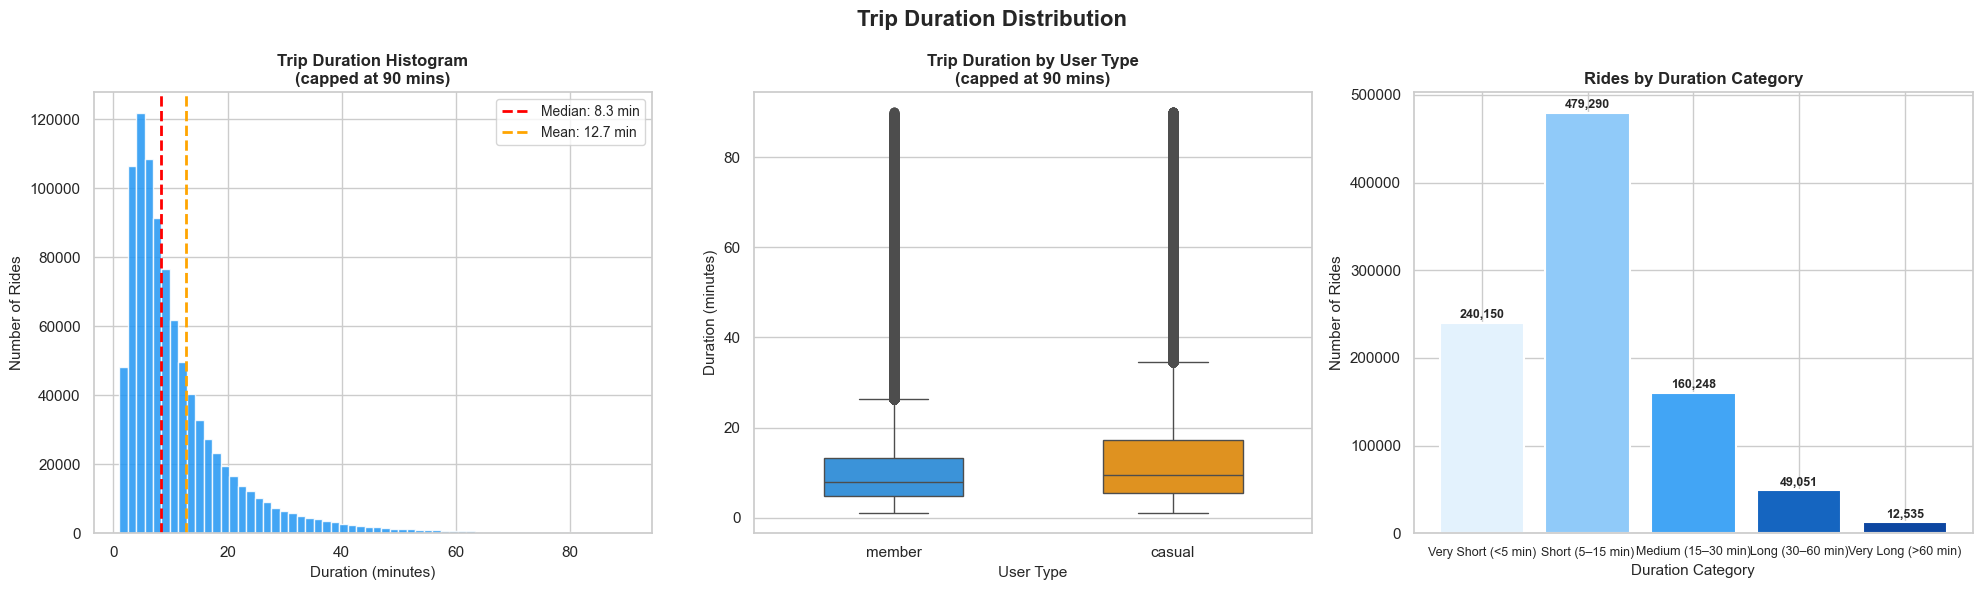

TRIP DURATION STATS BY USER TYPE
                  count  mean   std  min  25%  50%   75%     max
member_casual                                                   
casual        251912.00 16.36 33.51 1.00 5.60 9.65 17.70 1431.96
member        689362.00 11.30 19.27 1.00 4.74 7.90 13.42 1424.64


In [57]:
# ============================================================
# ANALYSIS 1.2: Trip Duration Distribution
# BUSINESS QUESTION: How long are typical trips?
# Are there unusually long or short ones?
# WHY IT MATTERS: Pricing tiers, bike availability planning, and detecting if the 45-min free ride limit is being used.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Trip Duration Distribution',
             fontsize=16, fontweight='bold')

# Cap at 90 mins for readability (removes extreme outliers visually)
df_plot = df[df['trip_duration_mins'] <= 90]

# --- Plot 1: Histogram ---
axes[0].hist(
    df_plot['trip_duration_mins'],
    bins=60,
    color='#2196F3',
    edgecolor='white',
    alpha=0.85
)
axes[0].axvline(
    df['trip_duration_mins'].median(),
    color='red', linestyle='--',
    linewidth=2, label=f"Median: {df['trip_duration_mins'].median():.1f} min"
)
axes[0].axvline(
    df['trip_duration_mins'].mean(),
    color='orange', linestyle='--',
    linewidth=2, label=f"Mean: {df['trip_duration_mins'].mean():.1f} min"
)
axes[0].set_title('Trip Duration Histogram\n(capped at 90 mins)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)', fontsize=11)
axes[0].set_ylabel('Number of Rides', fontsize=11)
axes[0].legend(fontsize=10)

# --- Plot 2: Boxplot by User Type ---
sns.boxplot(
    data=df[df['trip_duration_mins'] <= 90],
    x='member_casual',
    y='trip_duration_mins',
    palette={'member': '#2196F3', 'casual': '#FF9800'},
    ax=axes[1],
    width=0.5
)
axes[1].set_title('Trip Duration by User Type\n(capped at 90 mins)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('User Type', fontsize=11)
axes[1].set_ylabel('Duration (minutes)', fontsize=11)

# --- Plot 3: Duration Categories Bar ---
dur_counts = df['duration_category'].value_counts().sort_index()
colors_dur = ['#E3F2FD','#90CAF9','#42A5F5','#1565C0','#0D47A1']

bars = axes[2].bar(
    range(len(dur_counts)),
    dur_counts.values,
    color=colors_dur,
    edgecolor='white',
    linewidth=1.5
)
axes[2].set_xticks(range(len(dur_counts)))
axes[2].set_xticklabels(dur_counts.index, fontsize=9)
axes[2].set_title('Rides by Duration Category',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Number of Rides', fontsize=11)
axes[2].set_xlabel('Duration Category', fontsize=11)

for bar in bars:
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2000,
        f'{bar.get_height():,}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('02_trip_duration_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- Stats by User Type ---
print("=" * 45)
print("TRIP DURATION STATS BY USER TYPE")
print("=" * 45)
print(df.groupby('member_casual')['trip_duration_mins']
      .describe().round(2).to_string())

## **Analysis 1.3 — Top 10 Start & End Stations**

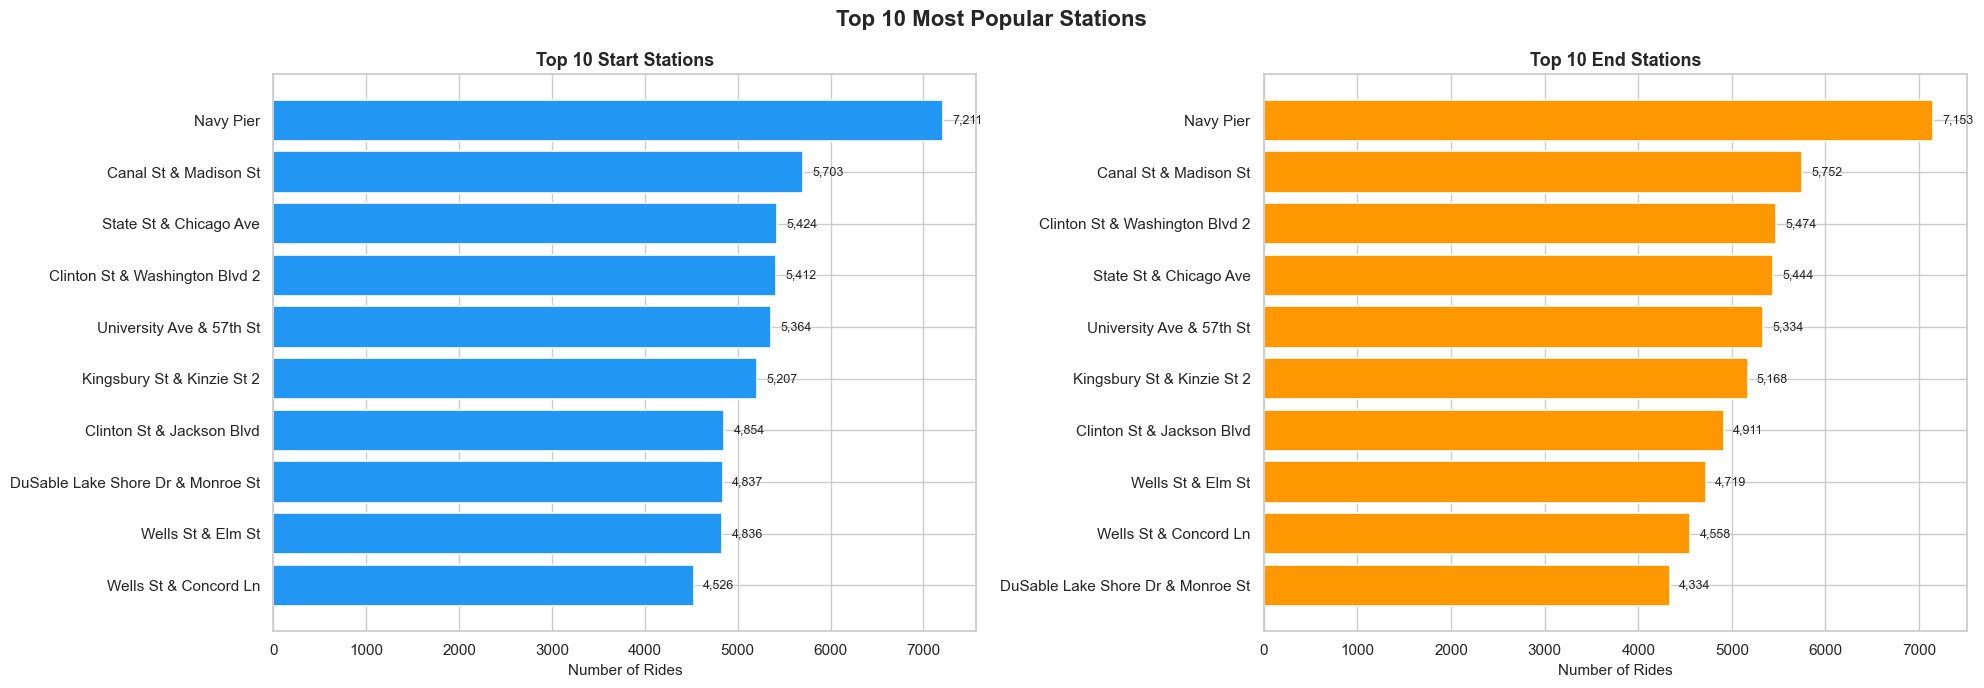

STATIONS IN BOTH TOP 10 START & END
Overlapping stations: 10
  • State St & Chicago Ave
  • Clinton St & Jackson Blvd
  • DuSable Lake Shore Dr & Monroe St
  • Wells St & Elm St
  • Kingsbury St & Kinzie St 2
  • University Ave & 57th St
  • Clinton St & Washington Blvd 2
  • Wells St & Concord Ln
  • Canal St & Madison St
  • Navy Pier


In [58]:
# ============================================================
# ANALYSIS 1.3: Most Popular Start & End Stations
# BUSINESS QUESTION: Where do rides begin and end most often?
# WHY IT MATTERS: Guides station expansion, bike rebalancing, and infrastructure investment decisions.
# NOTE: We exclude 'Unknown Station' (electric bike lock-ups) to focus on actual docking station popularity.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Top 10 Most Popular Stations',
             fontsize=16, fontweight='bold')

# Filter out Unknown Stations for this analysis
df_known = df[df['start_station_name'] != 'Unknown Station']

# Top 10 Start Stations
top_start = (df_known['start_station_name']
             .value_counts()
             .head(10)
             .sort_values())

# Top 10 End Stations
df_known_end = df[df['end_station_name'] != 'Unknown Station']
top_end = (df_known_end['end_station_name']
           .value_counts()
           .head(10)
           .sort_values())

# --- Plot 1: Start Stations ---
bars1 = axes[0].barh(
    top_start.index,
    top_start.values,
    color='#2196F3',
    edgecolor='white',
    linewidth=1.2
)
axes[0].set_title('Top 10 Start Stations',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Rides', fontsize=11)

for bar in bars1:
    axes[0].text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width()):,}',
        va='center', fontsize=9
    )

# --- Plot 2: End Stations ---
bars2 = axes[1].barh(
    top_end.index,
    top_end.values,
    color='#FF9800',
    edgecolor='white',
    linewidth=1.2
)
axes[1].set_title('Top 10 End Stations',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Rides', fontsize=11)

for bar in bars2:
    axes[1].text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width()):,}',
        va='center', fontsize=9
    )

plt.tight_layout()
plt.savefig('03_popular_stations.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- Overlap Check ---
print("=" * 45)
print("STATIONS IN BOTH TOP 10 START & END")
print("=" * 45)
overlap = set(top_start.index) & set(top_end.index)
print(f"Overlapping stations: {len(overlap)}")
for s in overlap:
    print(f"  • {s}")

# **📊 SECTION 2 — User Behavior Comparison**

## **Analysis 2.1 — Trip Duration Comparison**

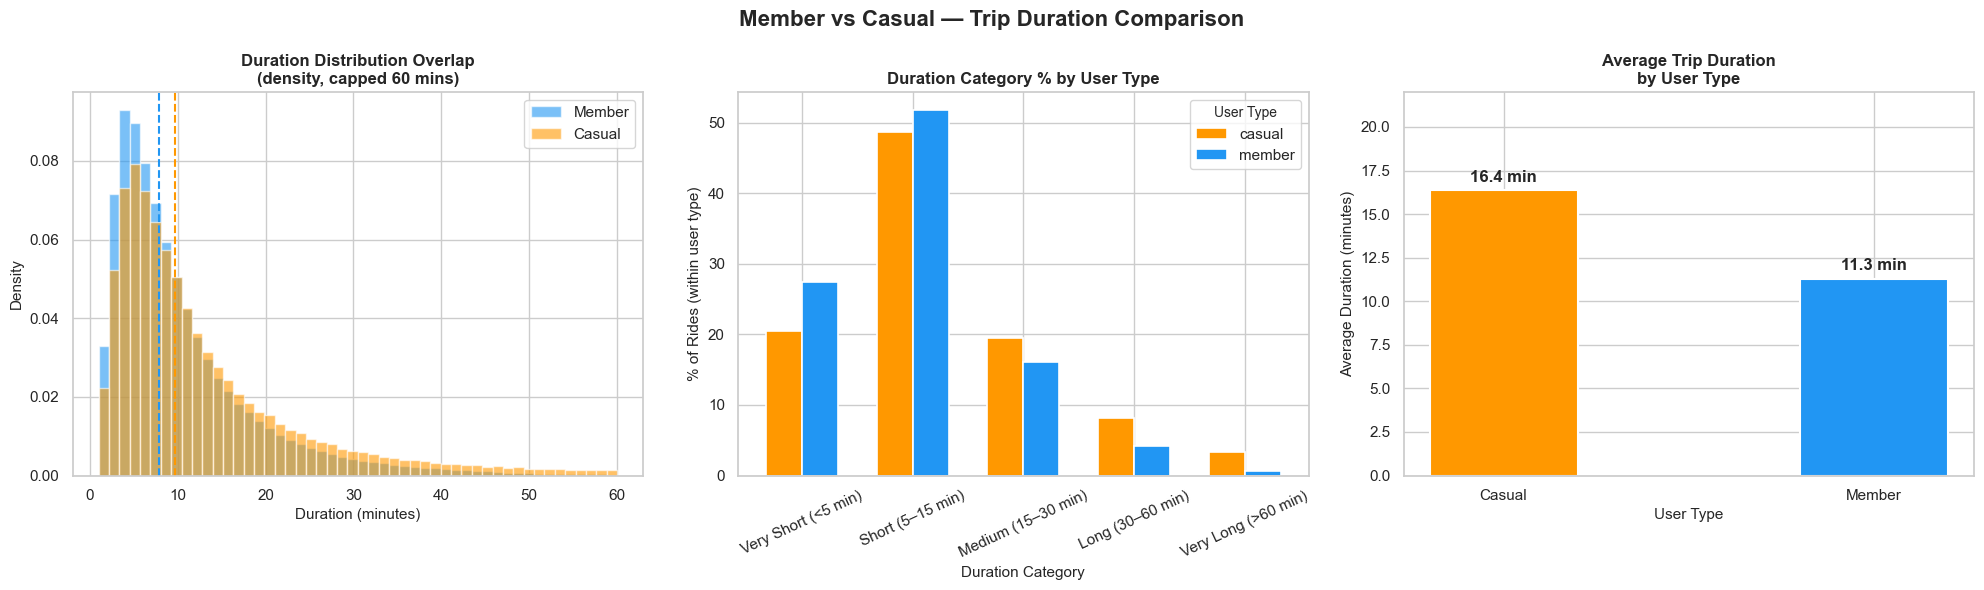

In [59]:
# ============================================================
# ANALYSIS 2.1: Trip Duration — Member vs Casual Deep Dive
# BUSINESS QUESTION: How differently do casuals and members actually ride? Duration is the clearest behavioral signal.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Member vs Casual — Trip Duration Comparison',
             fontsize=16, fontweight='bold')

colors = {'member': '#2196F3', 'casual': '#FF9800'}
df_plot = df[df['trip_duration_mins'] <= 60]

# --- Plot 1: Overlapping Histograms ---
for user_type, color in colors.items():
    subset = df_plot[df_plot['member_casual'] == user_type]
    axes[0].hist(
        subset['trip_duration_mins'],
        bins=50,
        alpha=0.6,
        color=color,
        label=user_type.title(),
        density=True   # normalize so both are comparable
    )

axes[0].set_title('Duration Distribution Overlap\n(density, capped 60 mins)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].axvline(9.65, color='#FF9800', linestyle='--',
                linewidth=1.5, label='Casual median')
axes[0].axvline(7.90, color='#2196F3', linestyle='--',
                linewidth=1.5, label='Member median')

# --- Plot 2: Duration Category by User Type ---
dur_user = (df.groupby(['duration_category', 'member_casual'])
              .size()
              .reset_index(name='count'))

dur_pivot = dur_user.pivot(
    index='duration_category',
    columns='member_casual',
    values='count'
).fillna(0)

# Normalize to % within each user type
dur_pct = dur_pivot.div(dur_pivot.sum(axis=0), axis=1) * 100

dur_pct.plot(
    kind='bar',
    ax=axes[1],
    color=[colors['casual'], colors['member']],
    edgecolor='white',
    linewidth=1.2,
    width=0.65
)
axes[1].set_title('Duration Category % by User Type',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Duration Category', fontsize=11)
axes[1].set_ylabel('% of Rides (within user type)', fontsize=11)
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='User Type', title_fontsize=10)

# --- Plot 3: Mean Duration Comparison ---
mean_dur = df.groupby('member_casual')['trip_duration_mins'].mean()
bars = axes[2].bar(
    mean_dur.index.str.title(),
    mean_dur.values,
    color=[colors['casual'], colors['member']],
    edgecolor='white',
    linewidth=1.5,
    width=0.4
)
axes[2].set_title('Average Trip Duration\nby User Type',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Average Duration (minutes)', fontsize=11)
axes[2].set_xlabel('User Type', fontsize=11)
axes[2].set_ylim(0, 22)

for bar in bars:
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f} min',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('04_duration_by_usertype.png',
            dpi=150, bbox_inches='tight')
plt.show()

## **Analysis 2.2 — Ride Frequency by Day of Week**

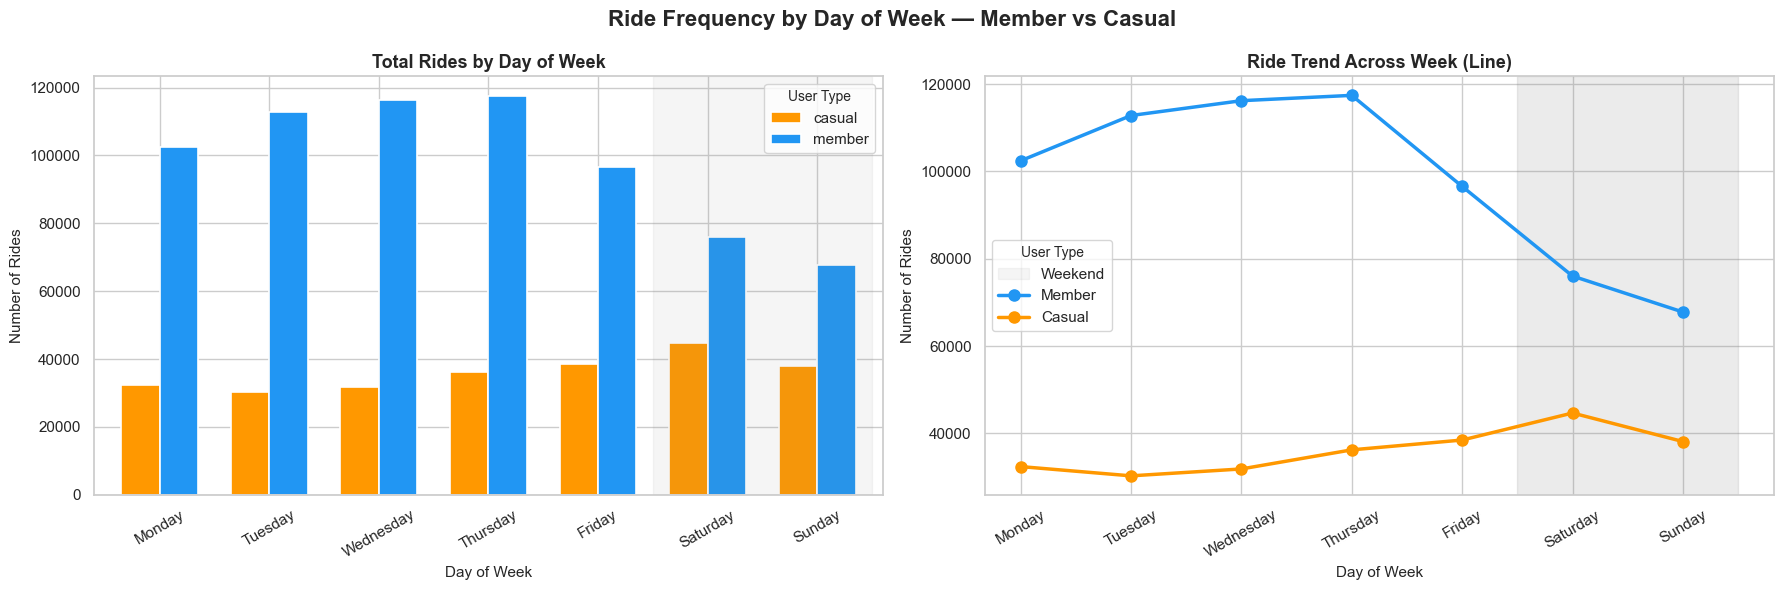

Rides by Day and User Type:
member_casual  casual  member
day_of_week                  
Monday          32376  102455
Tuesday         30254  112828
Wednesday       31836  116227
Thursday        36214  117448
Friday          38461   96577
Saturday        44657   76036
Sunday          38114   67791


In [60]:
# ============================================================
# ANALYSIS 2.2: Ride Frequency by Day of Week
# BUSINESS QUESTION: Which days do each user type prefer?
# HYPOTHESIS: Members peak midweek (commuting),
#             Casuals peak on weekends (leisure).
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Ride Frequency by Day of Week — Member vs Casual',
             fontsize=16, fontweight='bold')

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

# Rides per day by user type
day_user = (df.groupby(['day_of_week', 'member_casual'])
              .size()
              .reset_index(name='count'))

day_user['day_of_week'] = pd.Categorical(
    day_user['day_of_week'],
    categories=day_order,
    ordered=True
)
day_user = day_user.sort_values('day_of_week')

# --- Plot 1: Side-by-side bar ---
day_pivot = day_user.pivot(
    index='day_of_week',
    columns='member_casual',
    values='count'
)

day_pivot.plot(
    kind='bar',
    ax=axes[0],
    color=[colors['casual'], colors['member']],
    edgecolor='white',
    linewidth=1.2,
    width=0.7
)
axes[0].set_title('Total Rides by Day of Week',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day of Week', fontsize=11)
axes[0].set_ylabel('Number of Rides', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='User Type', title_fontsize=10)

# Add weekend shading
for ax in axes:
    ax.axvspan(4.5, 6.5, alpha=0.08,
               color='gray', label='Weekend')

# --- Plot 2: Line chart for trend clarity ---
for user_type, color in colors.items():
    subset = day_user[day_user['member_casual'] == user_type]
    axes[1].plot(
        subset['day_of_week'].astype(str),
        subset['count'],
        marker='o',
        linewidth=2.5,
        markersize=8,
        color=color,
        label=user_type.title()
    )

axes[1].set_title('Ride Trend Across Week (Line)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week', fontsize=11)
axes[1].set_ylabel('Number of Rides', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='User Type', title_fontsize=10)
axes[1].axvspan(4.5, 6.5, alpha=0.08, color='gray')

plt.tight_layout()
plt.savefig('05_rides_by_day.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Rides by Day and User Type:")
print(day_pivot.to_string())

## **Analysis 2.3 — Ride Frequency by Hour of Day**

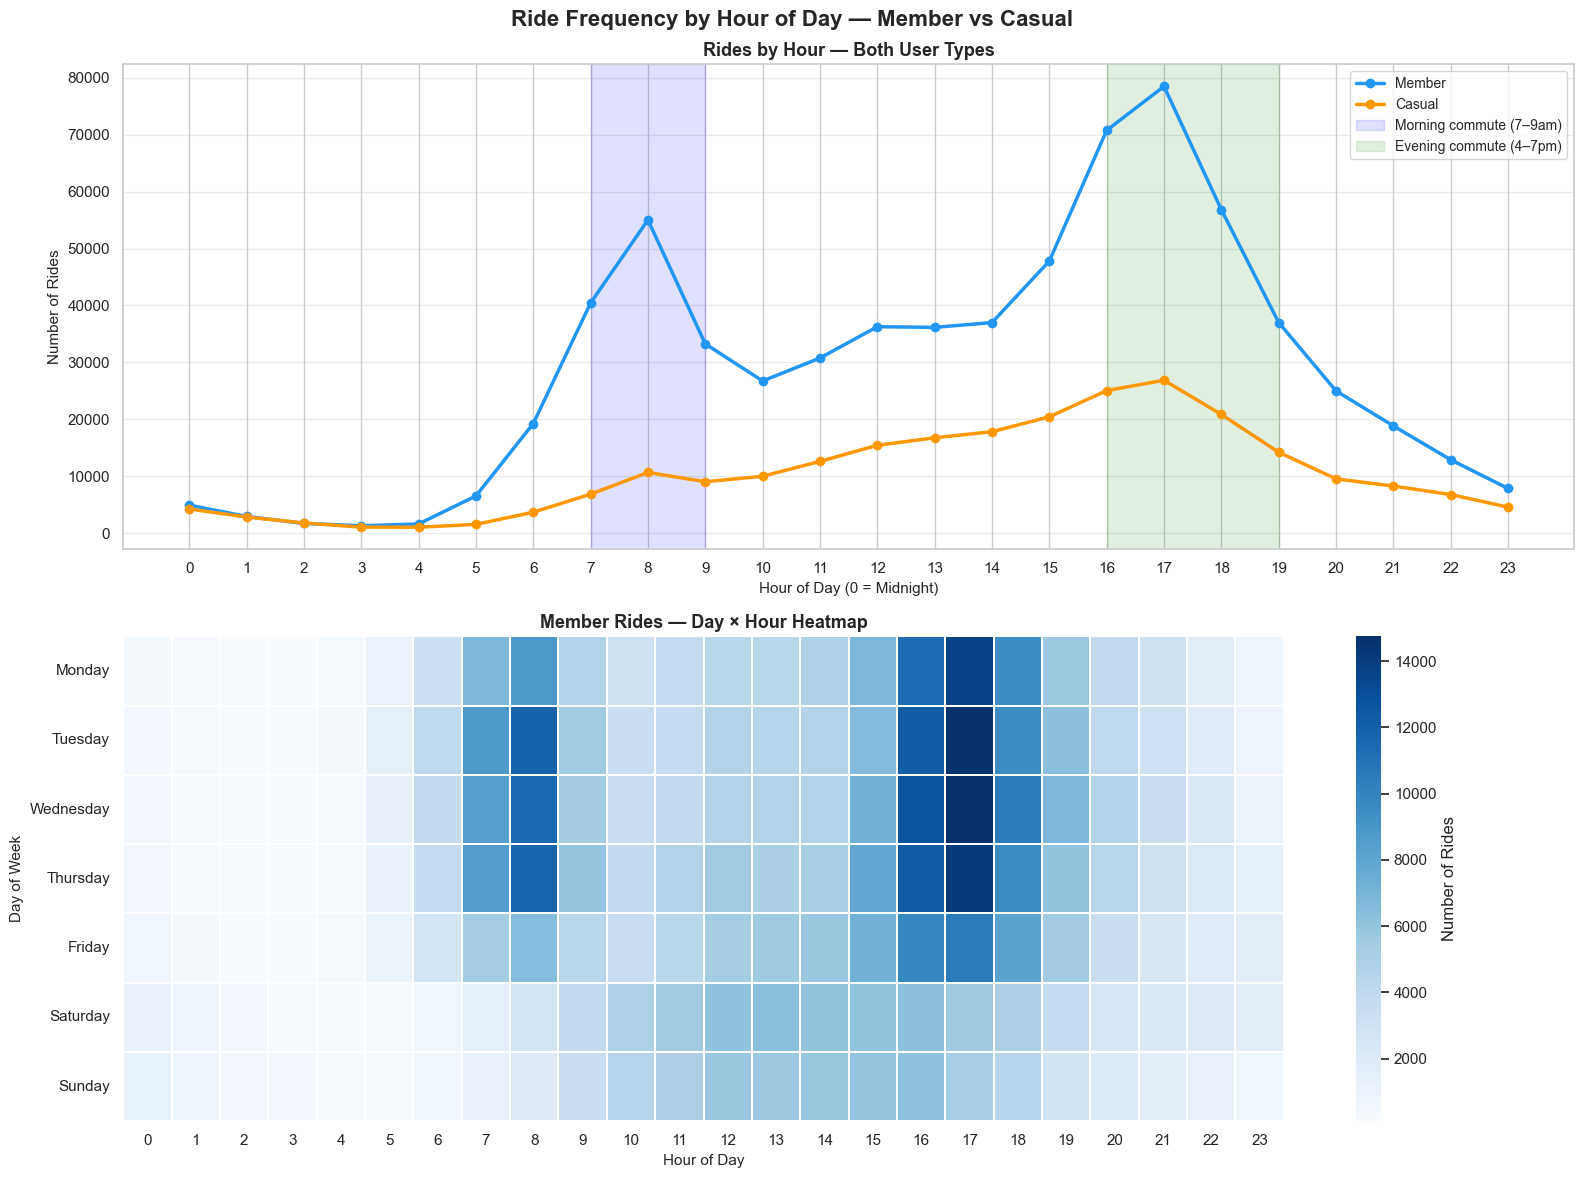

In [61]:
# ============================================================
# ANALYSIS 2.3: Ride Frequency by Hour of Day
# BUSINESS QUESTION: When during the day do each user type ride most?
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Ride Frequency by Hour of Day — Member vs Casual',
             fontsize=16, fontweight='bold')

hour_user = (df.groupby(['hour', 'member_casual'])
               .size()
               .reset_index(name='count'))

# --- Plot 1: Line chart ---
for user_type, color in colors.items():
    subset = hour_user[hour_user['member_casual'] == user_type]
    axes[0].plot(
        subset['hour'],
        subset['count'],
        marker='o',
        linewidth=2.5,
        markersize=6,
        color=color,
        label=user_type.title()
    )

# Shade commute hours
axes[0].axvspan(7, 9, alpha=0.12, color='blue',
                label='Morning commute (7–9am)')
axes[0].axvspan(16, 19, alpha=0.12, color='green',
                label='Evening commute (4–7pm)')

axes[0].set_title('Rides by Hour — Both User Types',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0 = Midnight)', fontsize=11)
axes[0].set_ylabel('Number of Rides', fontsize=11)
axes[0].set_xticks(range(0, 24))
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.4)

# --- Plot 2: Heatmap — Hour x Day x User ---
# Member heatmap
heat_data = (df[df['member_casual'] == 'member']
             .groupby(['day_of_week', 'hour'])
             .size()
             .reset_index(name='count'))

heat_pivot = heat_data.pivot(
    index='day_of_week',
    columns='hour',
    values='count'
).reindex(day_order).fillna(0)

sns.heatmap(
    heat_pivot,
    ax=axes[1],
    cmap='Blues',
    fmt='.0f',
    linewidths=0.3,
    cbar_kws={'label': 'Number of Rides'}
)
axes[1].set_title('Member Rides — Day × Hour Heatmap',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=11)
axes[1].set_ylabel('Day of Week', fontsize=11)

plt.tight_layout()
plt.savefig('06_rides_by_hour.png',
            dpi=150, bbox_inches='tight')
plt.show()

## **Analysis 2.4 — Preferred Bike Type by User**

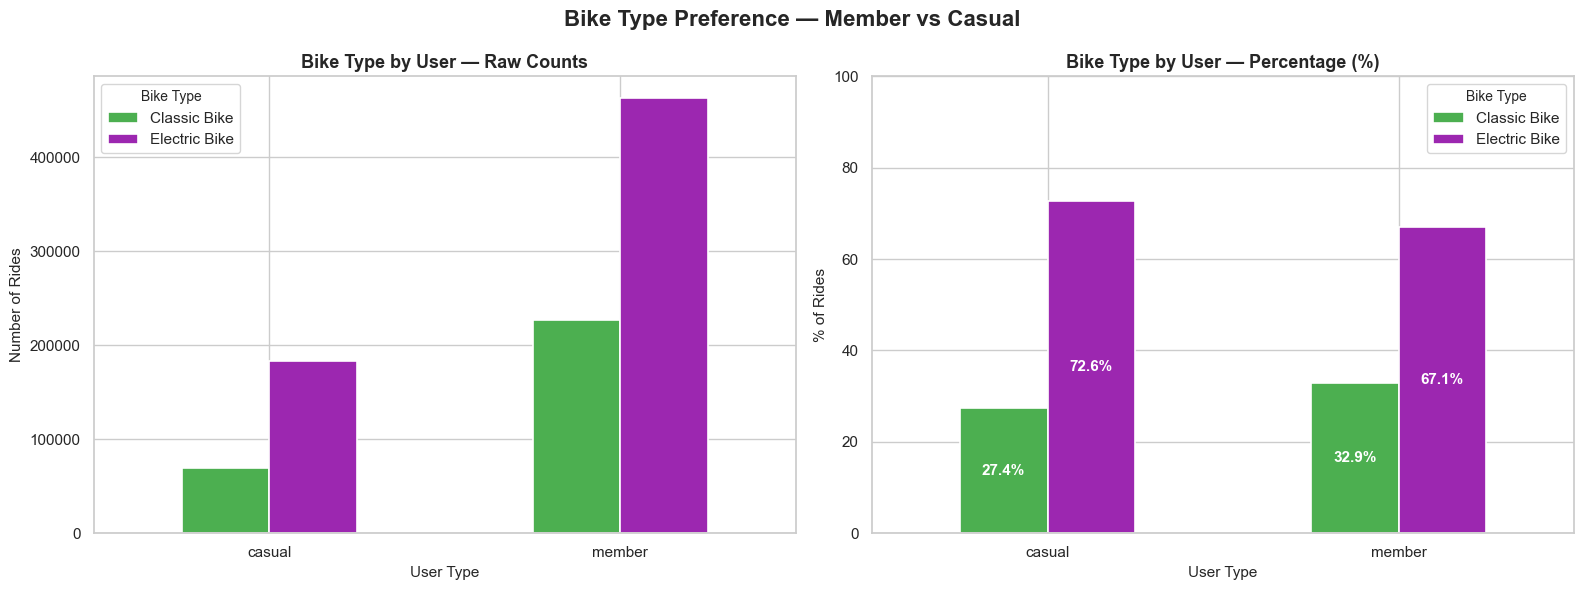


Bike Type % by User Type:
rideable_type  classic_bike  electric_bike
member_casual                             
casual                27.40          72.60
member                32.90          67.10


In [62]:
# ============================================================
# ANALYSIS 2.4: Preferred Rideable Type by User Type
# BUSINESS QUESTION: Do members and casuals prefer different bike types?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bike Type Preference — Member vs Casual',
             fontsize=16, fontweight='bold')

bike_user = pd.crosstab(
    df['member_casual'],
    df['rideable_type']
)

# --- Plot 1: Grouped bar (raw counts) ---
bike_user.plot(
    kind='bar',
    ax=axes[0],
    color=['#4CAF50', '#9C27B0'],
    edgecolor='white',
    linewidth=1.2,
    width=0.5
)
axes[0].set_title('Bike Type by User — Raw Counts',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('User Type', fontsize=11)
axes[0].set_ylabel('Number of Rides', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Bike Type',
               labels=['Classic Bike', 'Electric Bike'],
               title_fontsize=10)

# --- Plot 2: Normalized % ---
bike_pct = bike_user.div(bike_user.sum(axis=1), axis=0) * 100
bike_pct.plot(
    kind='bar',
    ax=axes[1],
    color=['#4CAF50', '#9C27B0'],
    edgecolor='white',
    linewidth=1.2,
    width=0.5
)
axes[1].set_title('Bike Type by User — Percentage (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('User Type', fontsize=11)
axes[1].set_ylabel('% of Rides', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 100)
axes[1].legend(title='Bike Type',
               labels=['Classic Bike', 'Electric Bike'],
               title_fontsize=10)

# Add % labels
for ax in [axes[1]]:
    for container in ax.containers:
        ax.bar_label(container,
                     fmt='%.1f%%',
                     label_type='center',
                     fontsize=11,
                     fontweight='bold',
                     color='white')

plt.tight_layout()
plt.savefig('07_bike_preference.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nBike Type % by User Type:")
print(bike_pct.round(1).to_string())

# **📊 SECTION 3 — Time-Based Patterns**

## **Analysis 3.1 — Peak Hours & Weekday vs Weekend**

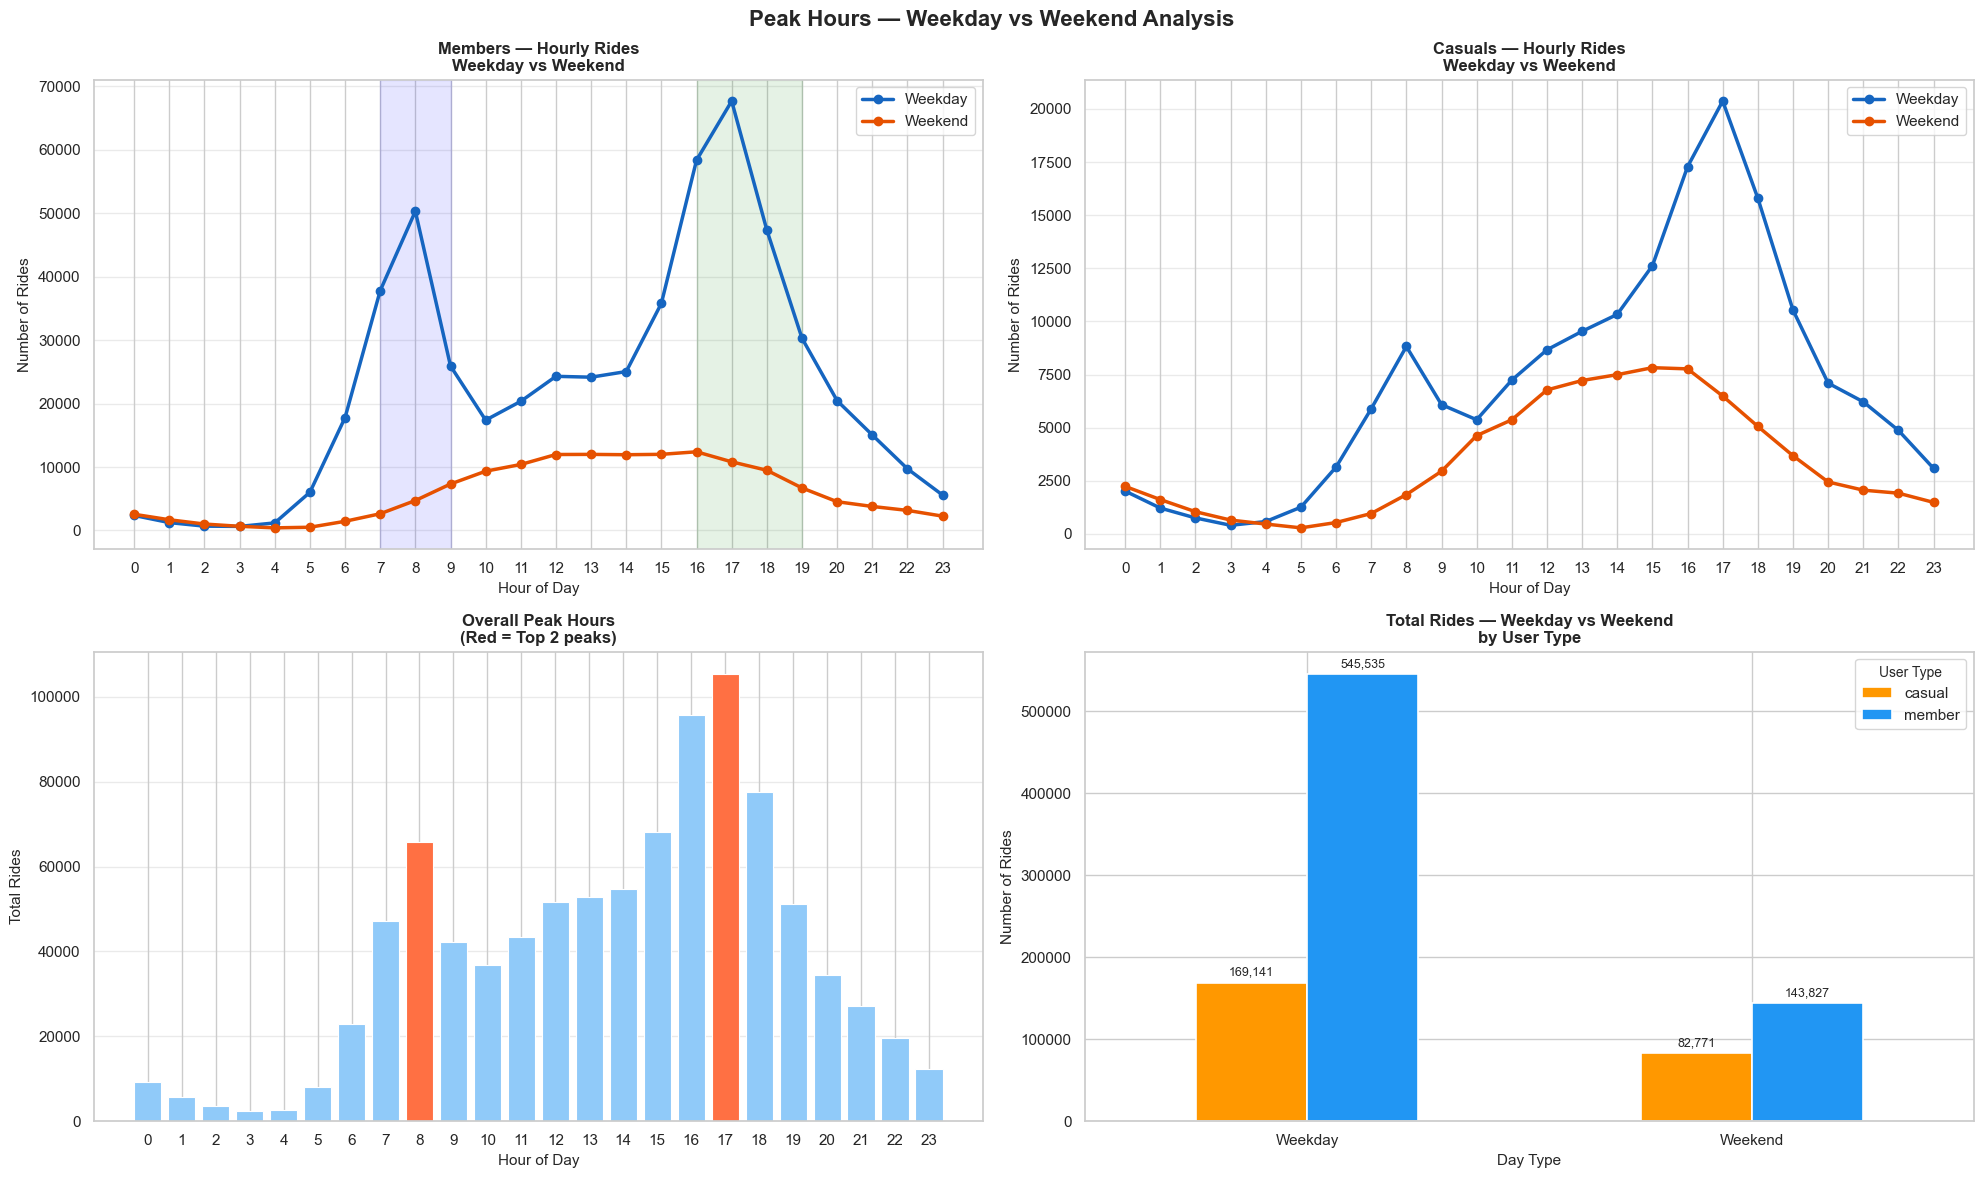

WEEKDAY vs WEEKEND — RIDES BY USER TYPE
member_casual  casual  member
day_type                     
Weekday        169141  545535
Weekend         82771  143827

--- Peak Hour Overall ---
hour
17    105349
16     95805
18     77693
15     68243
8      65697


In [63]:
# ============================================================
# ANALYSIS 3.1: Peak Hours — Weekday vs Weekend Comparison
# BUSINESS QUESTION: How does hourly usage differ betwee weekdays and weekends for each user type?
# WHY IT MATTERS: Station rebalancing schedules must be completely different on weekdays vs weekends.
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Peak Hours — Weekday vs Weekend Analysis',
             fontsize=16, fontweight='bold')

colors = {'member': '#2196F3', 'casual': '#FF9800'}
day_colors = {'Weekday': '#1565C0', 'Weekend': '#E65100'}

# --- Plot 1: Member — Weekday vs Weekend by Hour ---
for day_type, color in day_colors.items():
    subset = df[
        (df['member_casual'] == 'member') &
        (df['day_type'] == day_type)
    ].groupby('hour').size()

    axes[0,0].plot(
        subset.index, subset.values,
        marker='o', linewidth=2.5,
        markersize=6, color=color,
        label=day_type
    )

axes[0,0].set_title('Members — Hourly Rides\nWeekday vs Weekend',
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Hour of Day', fontsize=11)
axes[0,0].set_ylabel('Number of Rides', fontsize=11)
axes[0,0].set_xticks(range(0, 24))
axes[0,0].legend(fontsize=11)
axes[0,0].axvspan(7, 9, alpha=0.1, color='blue')
axes[0,0].axvspan(16, 19, alpha=0.1, color='green')
axes[0,0].grid(axis='y', alpha=0.4)

# --- Plot 2: Casual — Weekday vs Weekend by Hour ---
for day_type, color in day_colors.items():
    subset = df[
        (df['member_casual'] == 'casual') &
        (df['day_type'] == day_type)
    ].groupby('hour').size()

    axes[0,1].plot(
        subset.index, subset.values,
        marker='o', linewidth=2.5,
        markersize=6, color=color,
        label=day_type
    )

axes[0,1].set_title('Casuals — Hourly Rides\nWeekday vs Weekend',
                    fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Hour of Day', fontsize=11)
axes[0,1].set_ylabel('Number of Rides', fontsize=11)
axes[0,1].set_xticks(range(0, 24))
axes[0,1].legend(fontsize=11)
axes[0,1].grid(axis='y', alpha=0.4)

# --- Plot 3: Overall peak hours bar chart ---
peak_hour = df.groupby('hour').size().reset_index(name='count')
bar_colors = [
    '#FF7043' if h in [8, 17] else
    '#90CAF9' for h in peak_hour['hour']
]

bars = axes[1,0].bar(
    peak_hour['hour'],
    peak_hour['count'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)
axes[1,0].set_title('Overall Peak Hours\n(Red = Top 2 peaks)',
                    fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Hour of Day', fontsize=11)
axes[1,0].set_ylabel('Total Rides', fontsize=11)
axes[1,0].set_xticks(range(0, 24))
axes[1,0].grid(axis='y', alpha=0.4)

# --- Plot 4: Weekday vs Weekend total by user type ---
wk_user = (df.groupby(['day_type', 'member_casual'])
             .size()
             .reset_index(name='count'))

wk_pivot = wk_user.pivot(
    index='day_type',
    columns='member_casual',
    values='count'
)

wk_pivot.plot(
    kind='bar',
    ax=axes[1,1],
    color=[colors['casual'], colors['member']],
    edgecolor='white',
    linewidth=1.2,
    width=0.5
)
axes[1,1].set_title('Total Rides — Weekday vs Weekend\nby User Type',
                    fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Day Type', fontsize=11)
axes[1,1].set_ylabel('Number of Rides', fontsize=11)
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='User Type', title_fontsize=10)

# Add value labels
for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt='{:,.0f}',
                        fontsize=9, padding=3)

plt.tight_layout()
plt.savefig('08_peak_hours_weekday_weekend.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("=" * 50)
print("WEEKDAY vs WEEKEND — RIDES BY USER TYPE")
print("=" * 50)
print(wk_pivot.to_string())

print("\n--- Peak Hour Overall ---")
print(df.groupby('hour').size().nlargest(5)
      .rename('rides').to_string())

## **Analysis 3.2 — Monthly & Seasonal Trends**

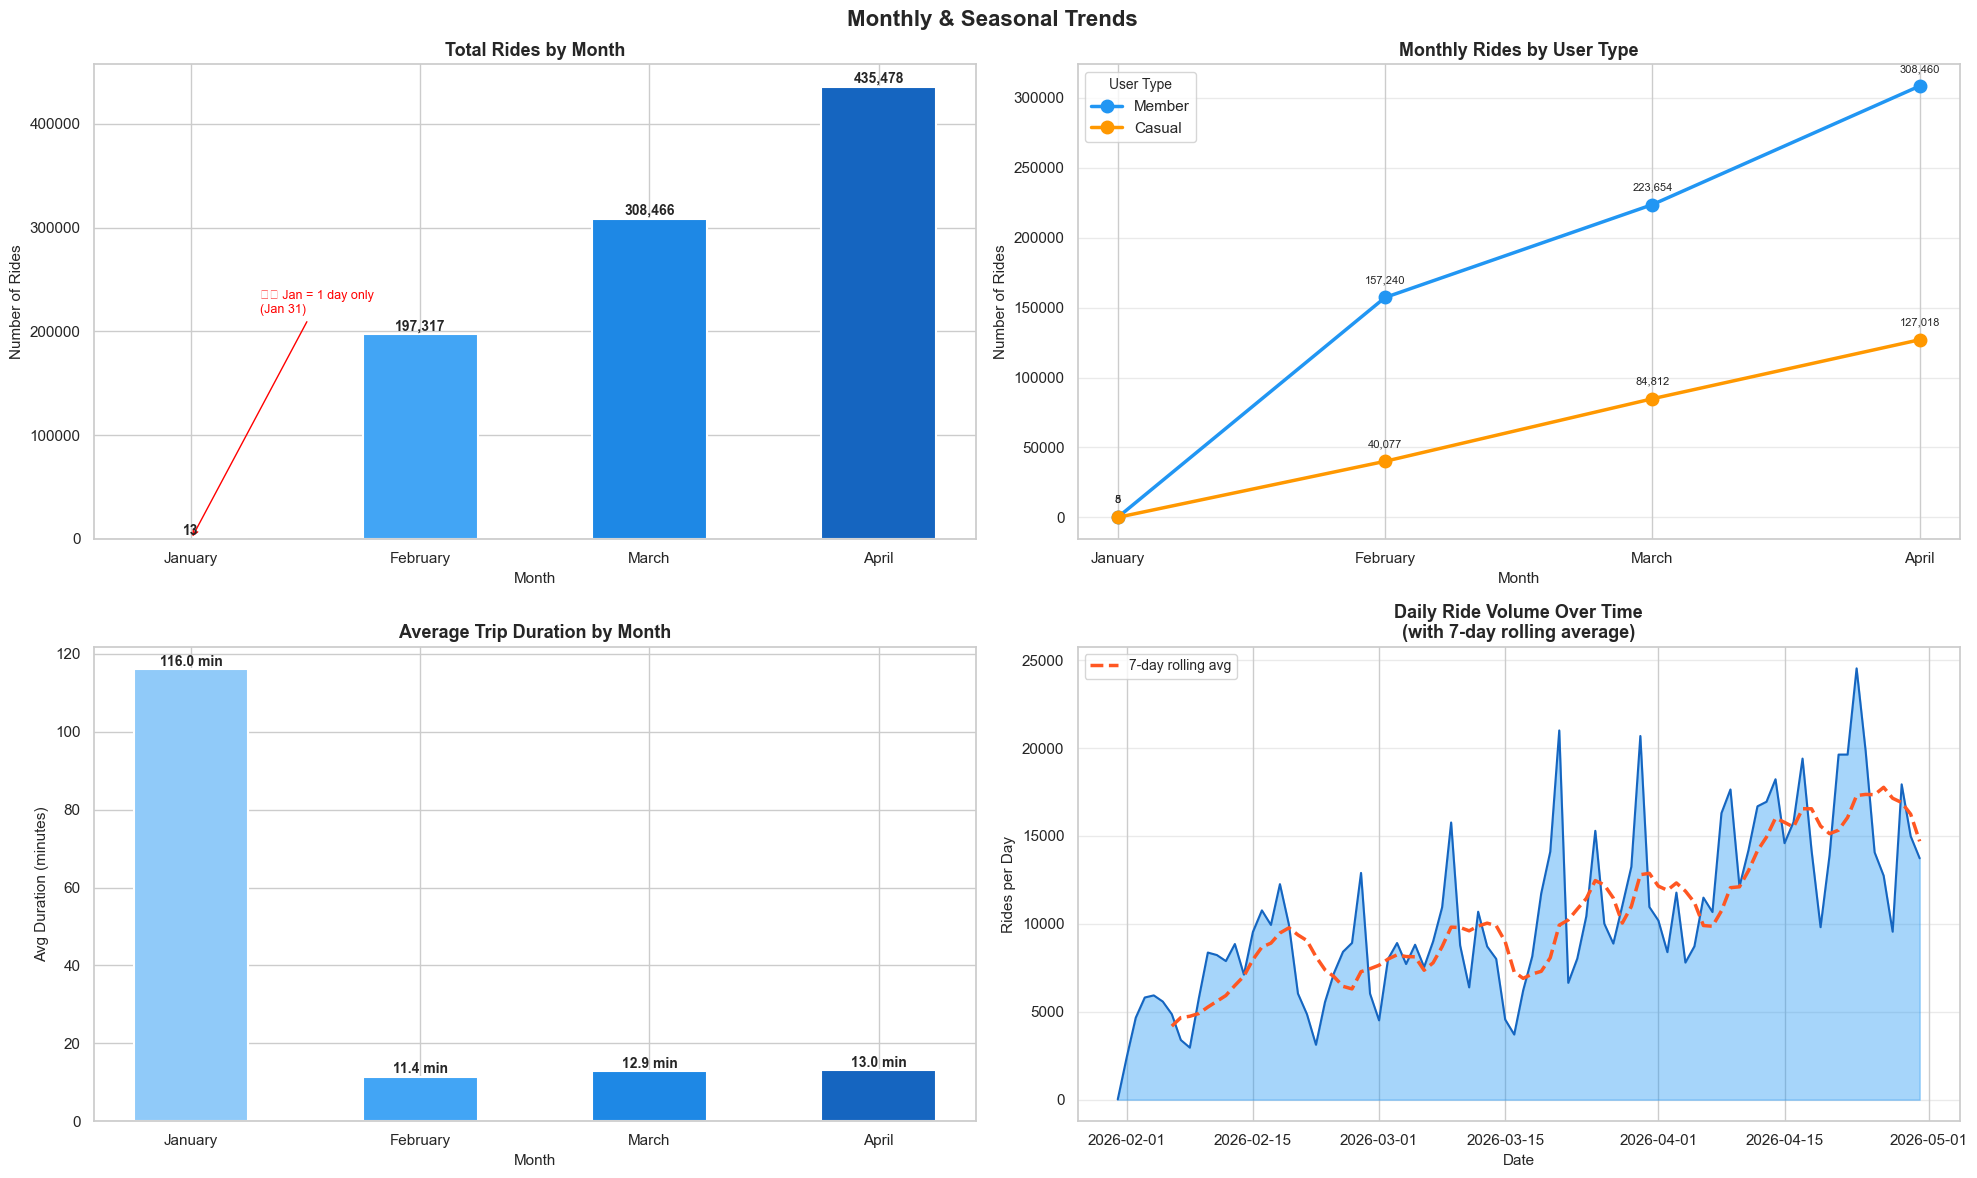

MONTHLY SUMMARY
month
January         13
February    197317
March       308466
April       435478

--- Average Duration by Month ---
month
January    116.03
February    11.45
March       12.87
April       13.05


In [64]:
# ============================================================
# ANALYSIS 3.2: Monthly Trends in Trip Volume
# BUSINESS QUESTION: Which months are busiest?
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Monthly & Seasonal Trends',
             fontsize=16, fontweight='bold')

month_order  = ['January', 'February', 'March', 'April']
month_colors = ['#90CAF9', '#42A5F5', '#1E88E5', '#1565C0']

# --- Plot 1: Total rides per month ---
monthly = (df.groupby(['month_num', 'month'])
             .size()
             .reset_index(name='count')
             .sort_values('month_num'))

bars = axes[0,0].bar(
    monthly['month'],
    monthly['count'],
    color=month_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
axes[0,0].set_title('Total Rides by Month',
                    fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Month', fontsize=11)
axes[0,0].set_ylabel('Number of Rides', fontsize=11)

# Flag January
axes[0,0].annotate(
    '⚠️ Jan = 1 day only\n(Jan 31)',
    xy=(0, monthly[monthly['month']=='January']['count'].values[0]),
    xytext=(0.3, monthly['count'].max() * 0.5),
    fontsize=9, color='red',
    arrowprops=dict(arrowstyle='->', color='red')
)

for bar in bars:
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# --- Plot 2: Monthly rides by User Type ---
monthly_user = (df.groupby(['month_num', 'month', 'member_casual'])
                  .size()
                  .reset_index(name='count')
                  .sort_values('month_num'))

for user_type, color in colors.items():
    subset = monthly_user[
        monthly_user['member_casual'] == user_type
    ]
    axes[0,1].plot(
        subset['month'],
        subset['count'],
        marker='o',
        linewidth=2.5,
        markersize=9,
        color=color,
        label=user_type.title()
    )
    # Add value labels on points
    for _, row in subset.iterrows():
        axes[0,1].annotate(
            f"{row['count']:,}",
            (row['month'], row['count']),
            textcoords='offset points',
            xytext=(0, 10),
            fontsize=8,
            ha='center'
        )

axes[0,1].set_title('Monthly Rides by User Type',
                    fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Month', fontsize=11)
axes[0,1].set_ylabel('Number of Rides', fontsize=11)
axes[0,1].legend(title='User Type', title_fontsize=10)
axes[0,1].grid(axis='y', alpha=0.4)

# --- Plot 3: Average trip duration by month ---
monthly_dur = (df.groupby(['month_num', 'month'])
                 ['trip_duration_mins']
                 .mean()
                 .reset_index()
                 .sort_values('month_num'))

axes[1,0].bar(
    monthly_dur['month'],
    monthly_dur['trip_duration_mins'],
    color=month_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
axes[1,0].set_title('Average Trip Duration by Month',
                    fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Month', fontsize=11)
axes[1,0].set_ylabel('Avg Duration (minutes)', fontsize=11)

for i, row in monthly_dur.iterrows():
    axes[1,0].text(
        i - monthly_dur.index[0],
        row['trip_duration_mins'] + 0.1,
        f"{row['trip_duration_mins']:.1f} min",
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# --- Plot 4: Daily ride volume over time (trend line) ---
daily_rides = (df.groupby('date')
                 .size()
                 .reset_index(name='count'))
daily_rides['date'] = pd.to_datetime(daily_rides['date'])

axes[1,1].fill_between(
    daily_rides['date'],
    daily_rides['count'],
    alpha=0.4, color='#2196F3'
)
axes[1,1].plot(
    daily_rides['date'],
    daily_rides['count'],
    color='#1565C0',
    linewidth=1.5
)

# Add 7-day rolling average
rolling = daily_rides.set_index('date')['count'].rolling(7).mean()
axes[1,1].plot(
    rolling.index,
    rolling.values,
    color='#FF5722',
    linewidth=2.5,
    label='7-day rolling avg',
    linestyle='--'
)

axes[1,1].set_title('Daily Ride Volume Over Time\n(with 7-day rolling average)',
                    fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Date', fontsize=11)
axes[1,1].set_ylabel('Rides per Day', fontsize=11)
axes[1,1].legend(fontsize=10)
axes[1,1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('09_monthly_seasonal_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("=" * 50)
print("MONTHLY SUMMARY")
print("=" * 50)
print(monthly.set_index('month')['count'].to_string())

print("\n--- Average Duration by Month ---")
print(monthly_dur.set_index('month')
      ['trip_duration_mins'].round(2).to_string())

# **📊 SECTION 4 — Deep Insights & Relationships**

## **Analysis 4.1 — Trip Duration vs Time of Day & Day of Week**

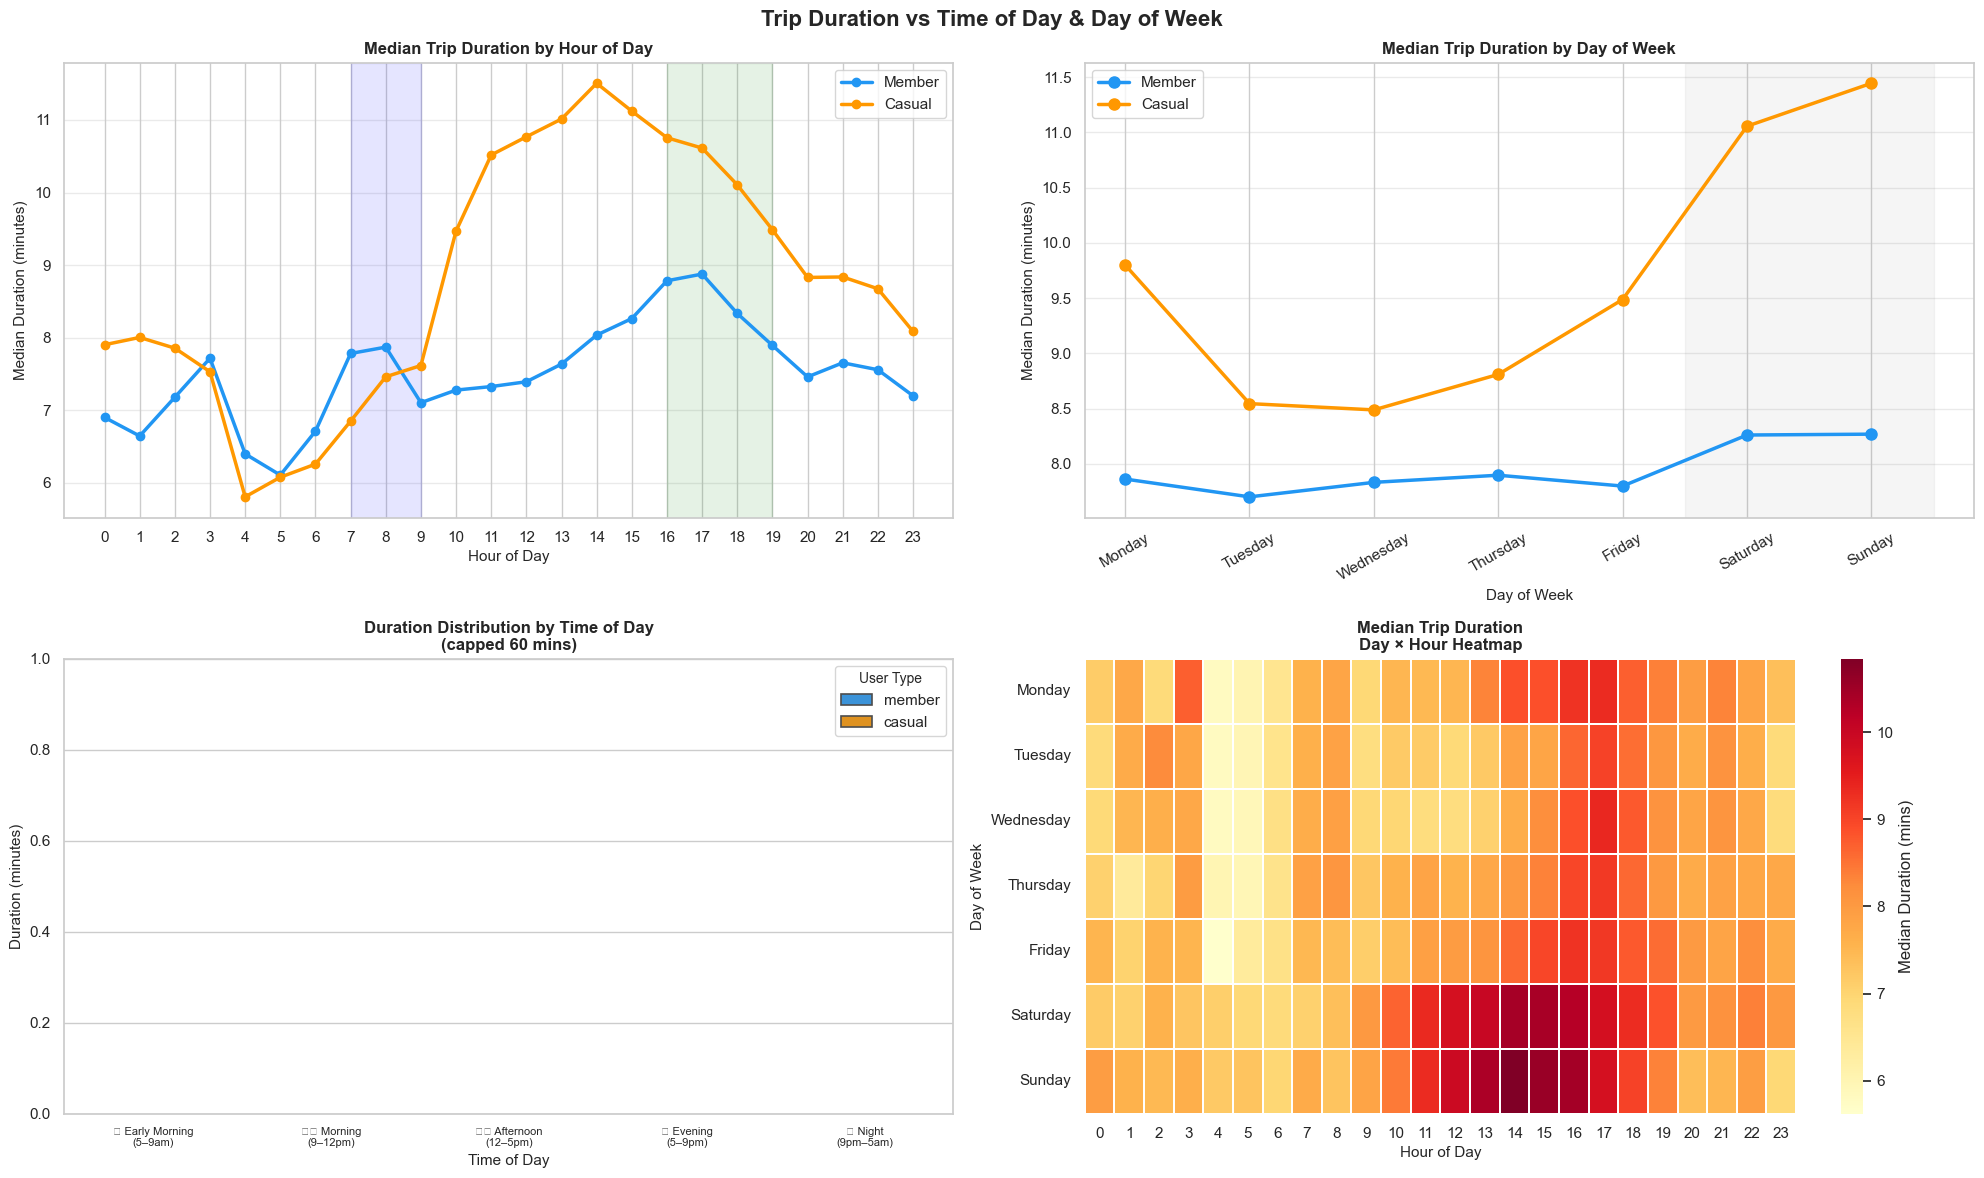

MEDIAN DURATION BY TIME OF DAY
time_of_day              member_casual
☀️ Afternoon (12–5pm)    casual          10.99
                         member           8.16
🌅 Early Morning (5–9am)  casual           6.95
                         member           7.56
🌆 Evening (5–9pm)        casual          10.01
                         member           8.35
🌙 Night (9pm–5am)        casual           8.30
                         member           7.38
🌤️ Morning (9–12pm)      casual           9.26
                         member           7.23

--- Median Duration by Day of Week ---
member_casual  casual  member
day_of_week                  
Monday           9.80    7.86
Tuesday          8.55    7.70
Wednesday        8.49    7.83
Thursday         8.81    7.90
Friday           9.49    7.80
Saturday        11.06    8.26
Sunday          11.44    8.27


In [66]:
# ============================================================
# ANALYSIS 4.1: Trip Duration vs Time of Day & Day of Week
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Trip Duration vs Time of Day & Day of Week',
             fontsize=16, fontweight='bold')

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
colors    = {'member': '#2196F3', 'casual': '#FF9800'}

time_order = [
    '🌅 Early Morning\n(5–9am)',
    '🌤️ Morning\n(9–12pm)',
    '☀️ Afternoon\n(12–5pm)',
    '🌆 Evening\n(5–9pm)',
    '🌙 Night\n(9pm–5am)'
]

# --- Plot 1: Median duration by hour ---
dur_hour = (df.groupby(['hour', 'member_casual'])
              ['trip_duration_mins']
              .median()
              .reset_index())

for user_type, color in colors.items():
    subset = dur_hour[dur_hour['member_casual'] == user_type]
    axes[0,0].plot(
        subset['hour'],
        subset['trip_duration_mins'],
        marker='o', linewidth=2.5,
        markersize=6, color=color,
        label=user_type.title()
    )

axes[0,0].set_title('Median Trip Duration by Hour of Day',
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Hour of Day', fontsize=11)
axes[0,0].set_ylabel('Median Duration (minutes)', fontsize=11)
axes[0,0].set_xticks(range(0, 24))
axes[0,0].legend(fontsize=11)
axes[0,0].grid(axis='y', alpha=0.4)
axes[0,0].axvspan(7, 9, alpha=0.1, color='blue')
axes[0,0].axvspan(16, 19, alpha=0.1, color='green')

# --- Plot 2: Median duration by day of week ---
dur_day = (df.groupby(['day_of_week', 'member_casual'])
             ['trip_duration_mins']
             .median()
             .reset_index())

dur_day['day_of_week'] = pd.Categorical(
    dur_day['day_of_week'],
    categories=day_order, ordered=True
)
dur_day = dur_day.sort_values('day_of_week')

for user_type, color in colors.items():
    subset = dur_day[dur_day['member_casual'] == user_type]
    axes[0,1].plot(
        subset['day_of_week'].astype(str),
        subset['trip_duration_mins'],
        marker='o', linewidth=2.5,
        markersize=8, color=color,
        label=user_type.title()
    )

axes[0,1].set_title('Median Trip Duration by Day of Week',
                    fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Day of Week', fontsize=11)
axes[0,1].set_ylabel('Median Duration (minutes)', fontsize=11)
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend(fontsize=11)
axes[0,1].grid(axis='y', alpha=0.4)
axes[0,1].axvspan(4.5, 6.5, alpha=0.08, color='gray')

# --- Plot 3: Violinplot — duration by time of day (FIXED) ---
df_box = df[df['trip_duration_mins'] <= 60].copy()
df_box['time_of_day'] = pd.Categorical(
    df_box['time_of_day'],
    categories=time_order, ordered=True
)

sns.violinplot(
    data=df_box,
    x='time_of_day',
    y='trip_duration_mins',
    hue='member_casual',
    palette=colors,
    ax=axes[1,0],
    inner='quartile',
    linewidth=1.2
)
axes[1,0].set_title('Duration Distribution by Time of Day\n(capped 60 mins)',
                    fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Time of Day', fontsize=11)
axes[1,0].set_ylabel('Duration (minutes)', fontsize=11)
axes[1,0].legend(title='User Type', title_fontsize=10)
axes[1,0].tick_params(axis='x', labelsize=8)

# --- Plot 4: Heatmap — median duration by day x hour ---
dur_heat = (df.groupby(['day_of_week', 'hour'])
              ['trip_duration_mins']
              .median()
              .reset_index())

dur_pivot = dur_heat.pivot(
    index='day_of_week',
    columns='hour',
    values='trip_duration_mins'
).reindex(day_order)

sns.heatmap(
    dur_pivot,
    ax=axes[1,1],
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Median Duration (mins)'}
)
axes[1,1].set_title('Median Trip Duration\nDay × Hour Heatmap',
                    fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Hour of Day', fontsize=11)
axes[1,1].set_ylabel('Day of Week', fontsize=11)

plt.tight_layout()
plt.savefig('10_duration_vs_time.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- Summary stats ---
print("=" * 50)
print("MEDIAN DURATION BY TIME OF DAY")
print("=" * 50)
print(df.groupby(['time_of_day', 'member_casual'])
      ['trip_duration_mins'].median().round(2).to_string())

print("\n--- Median Duration by Day of Week ---")
print(df.groupby(['day_of_week', 'member_casual'])
      ['trip_duration_mins'].median()
      .round(2).unstack().reindex(day_order).to_string())

## **Analysis 4.2 — Station Usage Patterns: Casual vs Member**

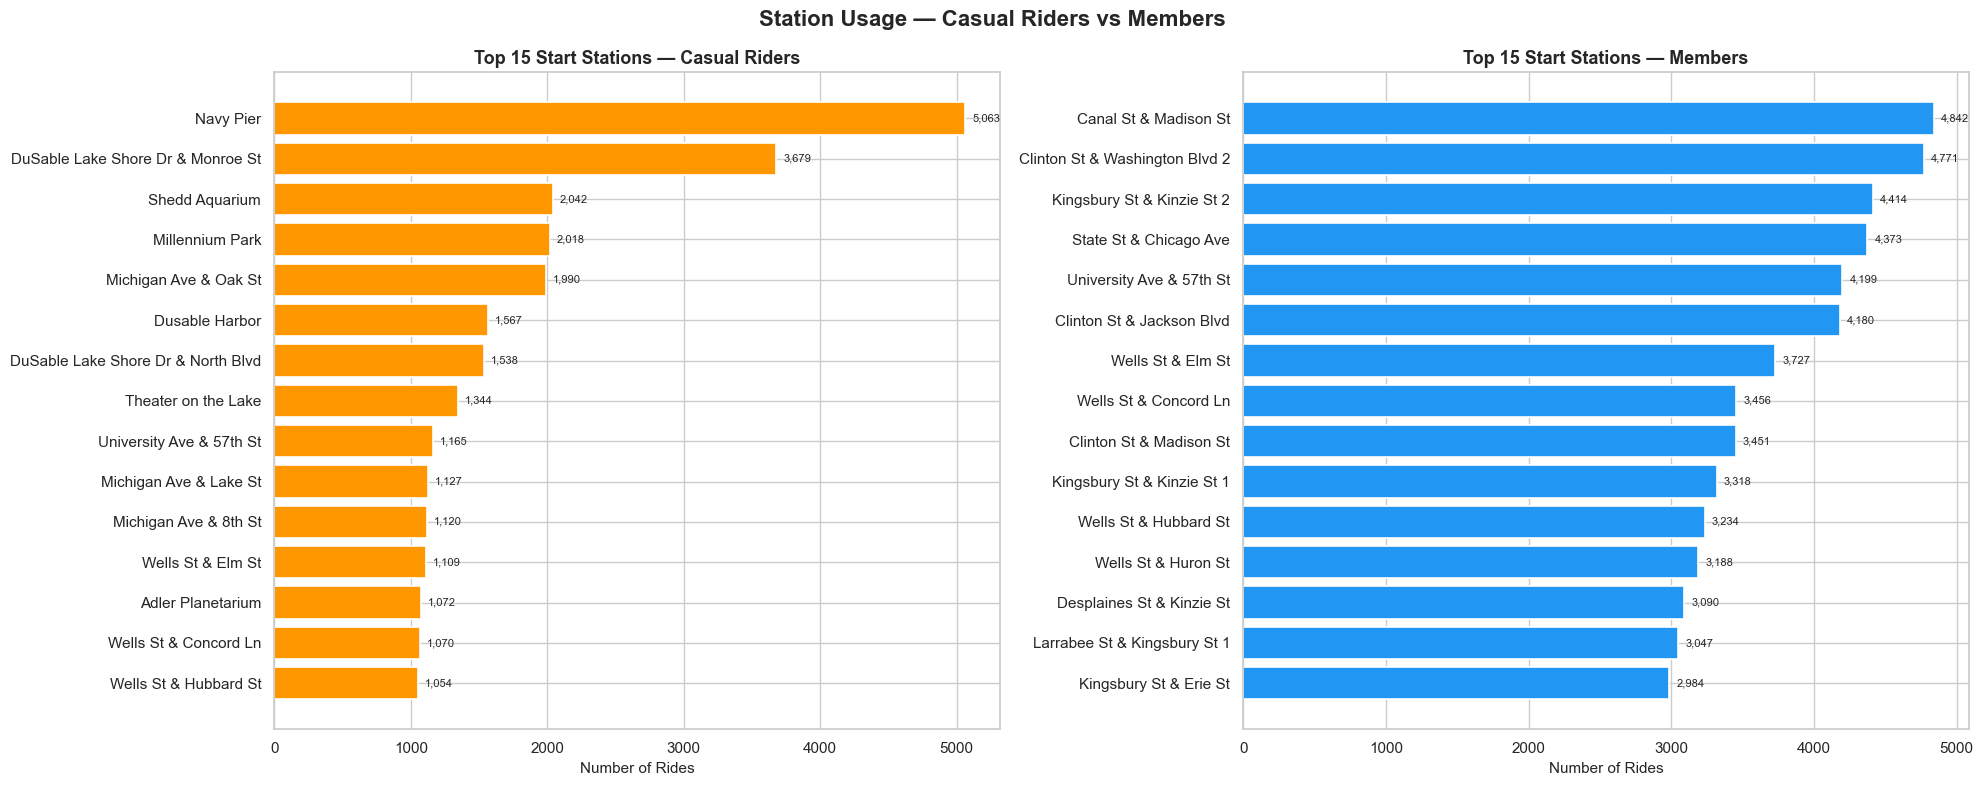

STATION OVERLAP ANALYSIS

Stations in BOTH top 15  : 4
  • University Ave & 57th St
  • Wells St & Concord Ln
  • Wells St & Elm St
  • Wells St & Hubbard St

Stations ONLY in Casual top 15 : 11
  • Adler Planetarium
  • DuSable Lake Shore Dr & Monroe St
  • DuSable Lake Shore Dr & North Blvd
  • Dusable Harbor
  • Michigan Ave & 8th St
  • Michigan Ave & Lake St
  • Michigan Ave & Oak St
  • Millennium Park
  • Navy Pier
  • Shedd Aquarium
  • Theater on the Lake

Stations ONLY in Member top 15 : 11
  • Canal St & Madison St
  • Clinton St & Jackson Blvd
  • Clinton St & Madison St
  • Clinton St & Washington Blvd 2
  • Desplaines St & Kinzie St
  • Kingsbury St & Erie St
  • Kingsbury St & Kinzie St 1
  • Kingsbury St & Kinzie St 2
  • Larrabee St & Kingsbury St 1
  • State St & Chicago Ave
  • Wells St & Huron St


In [67]:
# ============================================================
# ANALYSIS 4.2: Station Usage — Casual vs Member Patterns
# BUSINESS QUESTION: Do casual riders and members use
# different stations?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Station Usage — Casual Riders vs Members',
             fontsize=16, fontweight='bold')

df_known = df[df['start_station_name'] != 'Unknown Station']

# Top 15 stations for each user type
top_casual = (df_known[df_known['member_casual'] == 'casual']
              ['start_station_name']
              .value_counts()
              .head(15)
              .sort_values())

top_member = (df_known[df_known['member_casual'] == 'member']
              ['start_station_name']
              .value_counts()
              .head(15)
              .sort_values())

# --- Plot 1: Top 15 Casual Stations ---
axes[0].barh(
    top_casual.index,
    top_casual.values,
    color='#FF9800',
    edgecolor='white',
    linewidth=1.2
)
axes[0].set_title('Top 15 Start Stations — Casual Riders',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Rides', fontsize=11)

for i, (val, name) in enumerate(
        zip(top_casual.values, top_casual.index)):
    axes[0].text(val + 50, i, f'{val:,}',
                 va='center', fontsize=8)

# --- Plot 2: Top 15 Member Stations ---
axes[1].barh(
    top_member.index,
    top_member.values,
    color='#2196F3',
    edgecolor='white',
    linewidth=1.2
)
axes[1].set_title('Top 15 Start Stations — Members',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Rides', fontsize=11)

for i, (val, name) in enumerate(
        zip(top_member.values, top_member.index)):
    axes[1].text(val + 50, i, f'{val:,}',
                 va='center', fontsize=8)

plt.tight_layout()
plt.savefig('11_station_casual_vs_member.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- Overlap Analysis ---
casual_set = set(top_casual.index)
member_set = set(top_member.index)
overlap    = casual_set & member_set
only_casual = casual_set - member_set
only_member = member_set - casual_set

print("=" * 50)
print("STATION OVERLAP ANALYSIS")
print("=" * 50)
print(f"\nStations in BOTH top 15  : {len(overlap)}")
for s in sorted(overlap):
    print(f"  • {s}")

print(f"\nStations ONLY in Casual top 15 : {len(only_casual)}")
for s in sorted(only_casual):
    print(f"  • {s}")

print(f"\nStations ONLY in Member top 15 : {len(only_member)}")
for s in sorted(only_member):
    print(f"  • {s}")

## **Analysis 4.3 — Bonus Insight 1: Electric vs Classic Behavior**

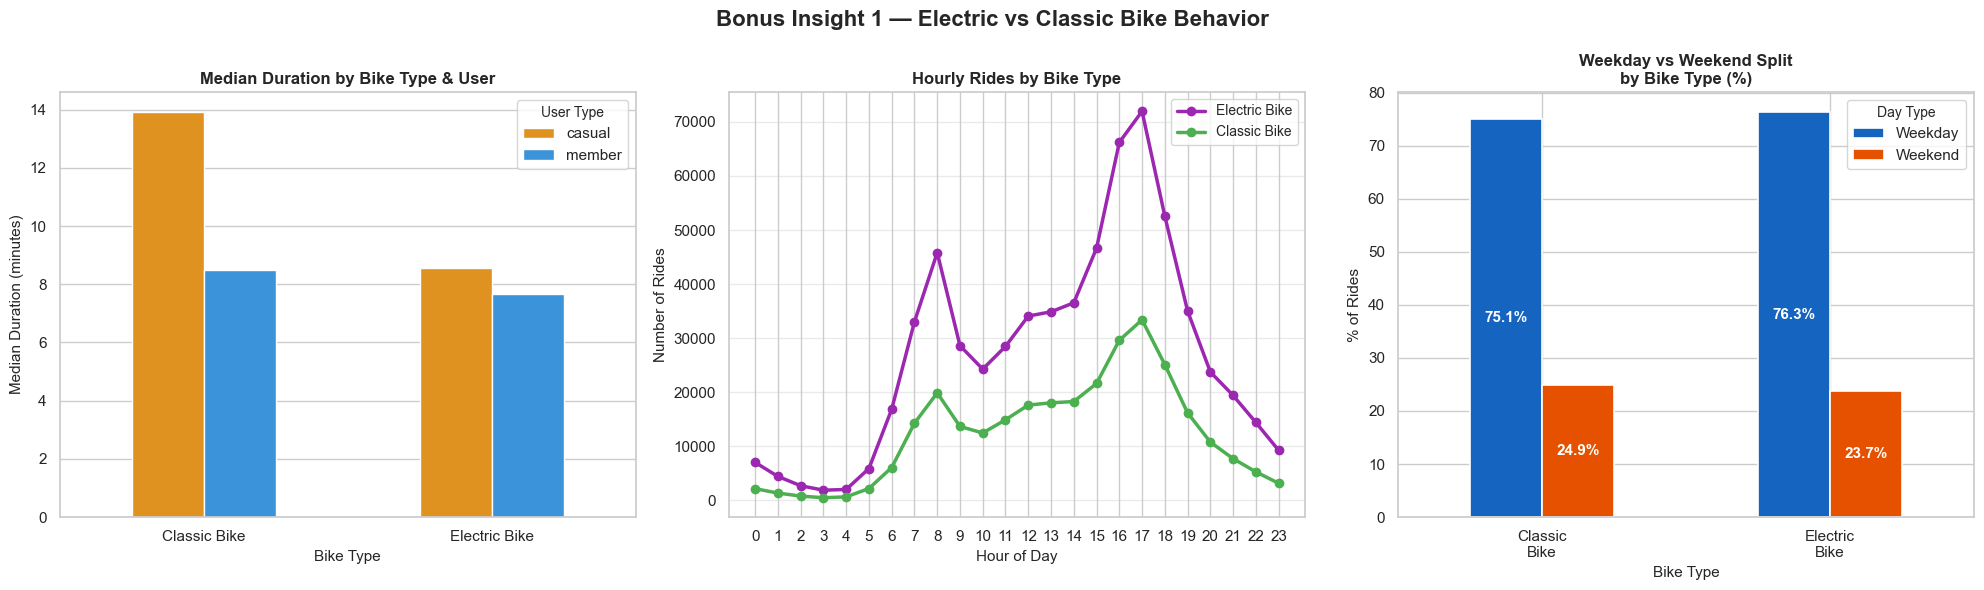

Median Duration by Bike Type:
rideable_type
classic_bike    9.47
electric_bike   7.89
Name: trip_duration_mins, dtype: float64


In [68]:
# ============================================================
# ANALYSIS 4.3: BONUS INSIGHT — Electric vs Classic Bikes
# BUSINESS QUESTION: Do riders behave differently depending on which bike type they choose?
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Bonus Insight 1 — Electric vs Classic Bike Behavior',
             fontsize=16, fontweight='bold')

bike_colors = {'electric_bike': '#9C27B0',
               'classic_bike' : '#4CAF50'}

# --- Plot 1: Avg duration by bike type & user ---
dur_bike = (df.groupby(['rideable_type', 'member_casual'])
              ['trip_duration_mins']
              .median()
              .reset_index())

sns.barplot(
    data=dur_bike,
    x='rideable_type',
    y='trip_duration_mins',
    hue='member_casual',
    palette=colors,
    ax=axes[0],
    width=0.5
)
axes[0].set_title('Median Duration by Bike Type & User',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bike Type', fontsize=11)
axes[0].set_ylabel('Median Duration (minutes)', fontsize=11)
axes[0].set_xticklabels(['Classic Bike', 'Electric Bike'])
axes[0].legend(title='User Type', title_fontsize=10)

# --- Plot 2: Hourly usage by bike type ---
hour_bike = (df.groupby(['hour', 'rideable_type'])
               .size()
               .reset_index(name='count'))

for bike, color in bike_colors.items():
    subset = hour_bike[hour_bike['rideable_type'] == bike]
    axes[1].plot(
        subset['hour'], subset['count'],
        marker='o', linewidth=2.5,
        markersize=6, color=color,
        label=bike.replace('_', ' ').title()
    )

axes[1].set_title('Hourly Rides by Bike Type',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=11)
axes[1].set_ylabel('Number of Rides', fontsize=11)
axes[1].set_xticks(range(0, 24))
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.4)

# --- Plot 3: Bike type by day type ---
bike_day = pd.crosstab(
    df['rideable_type'],
    df['day_type'],
    normalize='index'
) * 100

bike_day.index = bike_day.index.str.replace(
    '_', '\n').str.title()
bike_day.plot(
    kind='bar',
    ax=axes[2],
    color=['#1565C0', '#E65100'],
    edgecolor='white',
    linewidth=1.2,
    width=0.5
)
axes[2].set_title('Weekday vs Weekend Split\nby Bike Type (%)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Bike Type', fontsize=11)
axes[2].set_ylabel('% of Rides', fontsize=11)
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Day Type', title_fontsize=10)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f%%',
                      label_type='center',
                      fontsize=11, color='white',
                      fontweight='bold')

plt.tight_layout()
plt.savefig('12_electric_vs_classic.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Median Duration by Bike Type:")
print(df.groupby('rideable_type')
      ['trip_duration_mins'].median().round(2))